# 22.5 Fitting Phase with least-square fit

In this notebook, we show the algorithm of fitting initial phase with least square fit

# 0 seeting up signal

First, we read in the previously generated thermal noise.

In [ ]:
from scipy.optimize import least_squares
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [3]:
import h5py

h5_file = 'data\\2026-01-19 1024x2 noise data MeasureTime=0.011071397970549715 k=0.0027 T=273 Q=18000 f0=8169.7 initial ratio=100.h5'

with h5py.File(h5_file, "r") as f:
    sig_low = f["sig_low"][:]
    noise_0_low_l = f["noise_0_low_l"][:]
    noise_0_high_l = f["noise_0_high_l"][:]
    noise_eq = f["noise_eq"][:]


setting up cantilever parameters

In [4]:
Q = 18000
T = 273
k = 0.0027
w0 = 8169.7 * 2 * np.pi
dt = sig_low[1, 0] - sig_low[0, 0]
t = sig_low[:, 0] + sig_low[1, 0]  # time starts at dt

showing the noise, note that the unit is m (we gonna multiply it wth 10^9 when we use them.), and we can see the heating up pattern of the neg on noise.

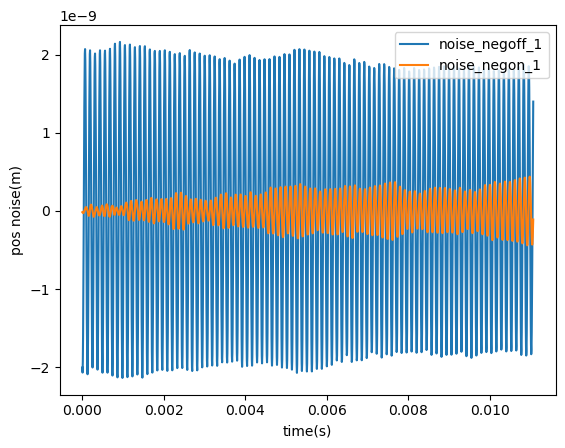

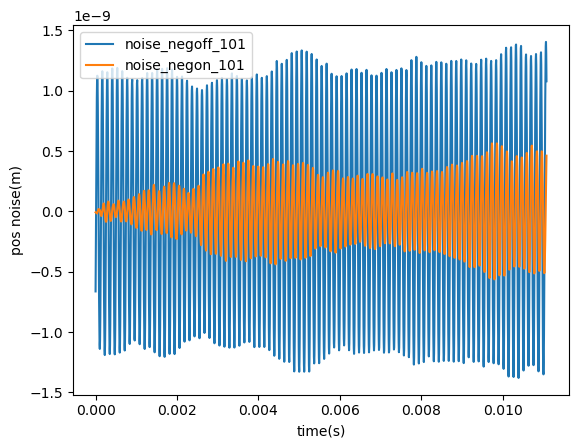

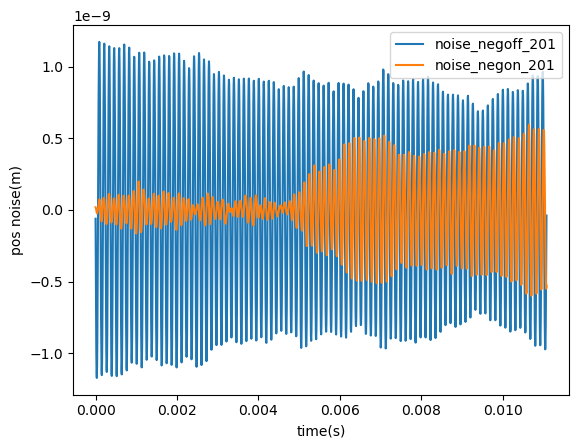

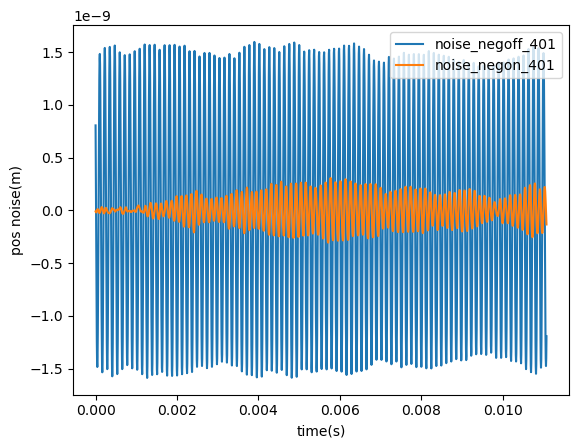

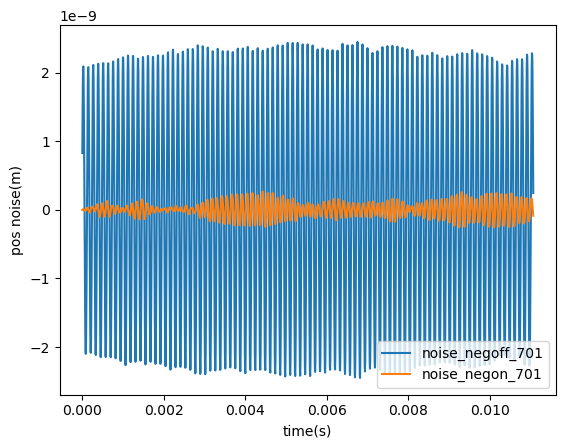

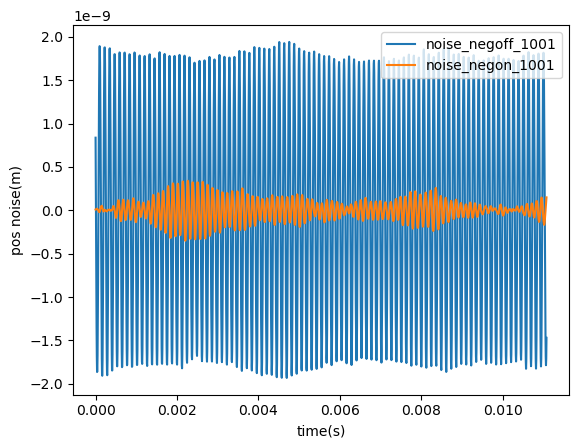

In [5]:
import matplotlib.pyplot as plt

for i in [1, 101, 201, 401, 701, 1001]:
    plt.plot(
        sig_low[:, 0],
        noise_eq[i * len(sig_low[:, 0]) : (i + 1) * len(sig_low[:, 0]), 0],
        label="noise_negoff_" + str(i),
    )
    plt.plot(sig_low[:, 0], noise_0_low_l[i][:, 0], label="noise_negon_" + str(i))
    plt.xlabel("time(s)")
    plt.ylabel("pos noise(m)")
    plt.legend()
    plt.show()

# 0.5 determining the shot noise amplitude:

The next step is determining the amplitude of shot noise, our signal has a form of $V0*np.sin(2*np.pi*(x+noise_{thermal})+/lam+phi_b)+V_{bias}+noise_{shot}$. And from the real signal, we draw a conclusion that our thermal noise has much bigger effect than the shot noise, however, as the thermal noise is within the sin function (generated on the cantilever) and the shot noise is generated out of the sin fucntion(generated on the detector), we can't compare their amplitude directly.

def the pos signal to voltage signal function.

In [6]:
def pos2sig(x, V0, lam, phi_b=0, V_bias=0):
    return V0 * np.sin(2 * np.pi * x / lam + phi_b) + V_bias

2.515581659042361e-12
-2.3593886892604473e-15


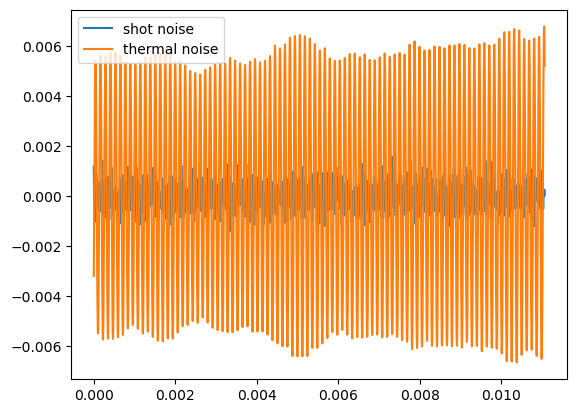

In [7]:
lam = 1300
x0 = 60

V0 = 1

N_cut = 100

std_shot = 0.0005
amp_sig = 1  # we assume that our initial ampltude for each trail is close, the ratio(~1) this used to adjust the amplitude
phi0_sig = 0.5 * np.pi * (np.random.rand() - 0.5)
V_b = 0
phi_b = 0
E = np.exp(-t * w0 / Q / 2)
j = 101
w = w0
noise_thermal = noise_eq[j * len(t) : (j + 1) * len(t), 0]
noise_shot = np.random.randn(len(t)) * std_shot

print(np.mean(noise_thermal))
print(np.mean(noise_eq[:, 0]))
V_noise_termal = pos2sig(1 * 10**9 * noise_thermal, V0, lam, phi_b=phi_b, V_bias=0)

import matplotlib.pyplot as plt


plt.plot(sig_low[:, 0], noise_shot, label="shot noise")
plt.plot(sig_low[:, 0], V_noise_termal, label="thermal noise")
plt.legend()
plt.show()

This is basicly what we saw in the experiment.

# 1 setting up function

We want to use hilbert filter to extract the phase. We defne 2 function:

1.getCantileverHilbertFilter()is used to apply hilbert filter on the pos signal, outputing the complex form of signal

2.getCantileverFreq() is used to extract the phase from pos signal and fitting its slope to get the frequency.

There is another way to extract parameters from the signal: using non-linear least square fit.



In [ ]:
import function as fc


def getCantileverHilbertFilter(
    data,
    t_cycle,
    f_band,
    t_rip,
    if_window,
    if_bandpass,
    if_rippleless,
    bpstyle="brick wall",
):

    # create numpy array from incoming waveform
    arr = np.array(data)
    # extract ordinate data array
    x, y = arr[:, 0], arr[:, 1]
    # time step
    dt = x[1] - x[0]
    # # apply time mask
    # x, y = fc.time_mask_binarate(x, y, dt, "start")
    # force data to start/end at zero, prevent edge effect on the beginning and end of the signal
    if if_window:
        w = fc.time_window_cyclicize(x, y, dt, t_cycle)
        y = y * w
    # fourier transform (F.T.)
    freq, sFT = fc.fft(x, y, dt)
    # complex Hilbert transform
    filt = fc.freq_filter_Hilbert_complex(freq, sFT)
    if if_bandpass:
        # apply 1kHz wide bandpass filter
        bp = fc.freq_filter_bp(freq, sFT, filt, f_band, style=bpstyle)
    else:
        bp = sFT
    # set up filter to remove ripples
    if if_rippleless:
        mask, x_rippleless = fc.time_mask_rippleless(x, dt, t_rip)
    else:
        mask = np.ones_like(x, dtype=bool)
    # Inverse F.T.
    sIFT, p, a = fc.ifft(sFT, dt, filt, bp, mask)
    # fit phase vs. time data
    # x_sub_middle, slope = fit_phase(sIFT, p, a, dt, x, 221.34E-6)
    # # compute average fc
    # avg_fc = np.mean(slope)

    return sIFT


def getCantileverFreq(
    data, t_cycle, t_rip, dt_chunk_target=221.34e-6, bpstyle="gaussian"
):

    # create numpy array from incoming waveform
    arr = np.array(data)
    # extract ordinate data array
    x, y = arr[:, 0], arr[:, 1]
    # time step
    dt = x[1] - x[0]
    # apply time mask
    # x, y = time_mask_binarate(x, y, dt, "middle")
    # force data to start/end at zero, prevent edge effect on the beginning and end of the signal
    w = fc.time_window_cyclicize(x, y, dt, t_cycle)
    # apply cyclicizing window to signal
    y = y * w
    # fourier transform (F.T.)
    freq, sFT = fc.fft(x, y, dt)
    # complex Hilbert transform
    filt = fc.freq_filter_Hilbert_complex(freq, sFT)
    # apply 1kHz wide bandpass filter
    bp = fc.freq_filter_bp(freq, sFT, filt, 1.00, style=bpstyle)
    # set up filter to remove ripples
    mask, x_rippleless = fc.time_mask_rippleless(x, dt, t_rip)
    # Inverse F.T.
    sIFT, p, a = fc.ifft(sFT, dt, filt, bp, mask)
    # fit phase vs. time data
    x_sub_middle, slope = fc.fit_phase(sIFT, p, a, dt, x, dt_chunk_target)
    # compute average fc
    avg_fc = np.mean(slope)

    return slope

In [ ]:
import numpy as np
from scipy.optimize import least_squares


def fit_many_warmstart(
    Y, t, E, V0, p0, bounds=None, loss="huber", x_scale=None, method="dogbox"
):
    """
    This function is used to fit our signal with warm start method, wo cut our signal into small
    pieces, and when we fit it, we want to approx the initial guess for the Ith trail by the
    fitting result of (I-1)th trail, which is called warm start.
    Parameters:
        Y [list of array]: each array is the signal we want to fit, which is a 2D array with the
        first column as the time and the second column as the signal.
        t [array]: the time array of the signal.
        E [array]: the envelope array of the signal.
        V0 [float]: the V0 of the signal.
        p0 [array]: the initial guess of the parameters.
        bounds [tuple]: the bounds of the parameters.
        loss [str]: the loss function we want to use.
        x_scale [array]: the scale of the parameters.
        method [str]: the method we want to use to fit the signal.
    Returns:
        P [array]: the fitting result of the parameters.
        costs [array]: the cost of the fitting.
        nfevs [array]: the number of function evaluations.
    """
    fun, jac = make_fun_jac(t, E, V0)

    n_seg = len(Y)
    P = np.empty((n_seg, 4), float)
    costs = np.empty(n_seg, float) 
    nfevs = np.empty(n_seg, int)  
    p = np.array(p0, float)

    if x_scale is None:
        x_scale = [
            np.max([np.abs(bounds[1][i] - bounds[0][i]), 1e-10])
            for i in range(len(bounds[0]))
        ]

    for i, y in enumerate(Y):
        res = least_squares(
            lambda pp: fun(pp, y),
            x0=p,
            jac=lambda pp: jac(pp, y),
            method=method,
            bounds=bounds if bounds is not None else (-np.inf, np.inf),
            loss=loss,
            x_scale=x_scale,
            max_nfev=50,  
            xtol=1e-15,
            ftol=1e-15,
            gtol=1e-15,
        )

        P[i] = res.x
        if n_seg > 1:
            p = P[i]
            p[1] = (t[-1] + t[1] - t[0]) * P[i][-1] + p[1]
            p[1] = (p[1] + np.pi) % (2 * np.pi) - np.pi  # Transfering phase to[-pu,pi]
            p[0] = P[i][0] * E[-1] * E[1] / E[0]
            if bounds is not None:
                bounds[0][0] = bounds[0][0] * E[-1] * E[1] / E[0]
                bounds[1][0] = bounds[1][0] * E[-1] * E[1] / E[0]
        costs[i] = res.cost
        nfevs[i] = res.nfev
    return P, costs, nfevs


def makey(t, E, V0, x0, phi0, phiB, w):
    psi = w * t + phi0
    cpsi = np.cos(psi)
    Theta = x0 * E * cpsi + phiB
    sTh = np.sin(Theta)
    yhat = V0 * sTh
    return yhat


def makeJ(t, E, V0, x0, phi0, phiB, w):
    psi = w * t + phi0
    cpsi = np.cos(psi)
    spsi = np.sin(psi)

    Theta = x0 * E * cpsi + phiB
    sTh = np.sin(Theta)
    cTh = np.cos(Theta)

    J = np.empty((t.size, 4), dtype=float)  # d yhat / d params
    J[:, 0] = V0 * cTh * (E * cpsi)
    J[:, 1] = V0 * cTh * (-x0 * E * spsi)
    J[:, 2] = V0 * cTh
    J[:, 3] = V0 * cTh * (-x0 * E * t * spsi)
    return J


def make_fun_jac(t, E, V0):
    t = np.asarray(t, float)

    def fun(p, y):
        x0, phi0, phiB, w = p
        yhat = makey(t, E, V0, x0, phi0, phiB, w)
        return y - yhat

    def jac(p, y):
        x0, phi0, phiB, w = p
        J = makeJ(t, E, V0, x0, phi0, phiB, w)
        return -J  # residual 的导数

    return fun, jac

# 2 Fitting the data

Then we begin to fit our signal: we have 1024 trails of high-freq signal(8169.45Hz) and 1024 trails of low-freq signal(8169.4Hz), we generate the signal analytically, and mannually add thermal noise and shot noise to it. Rememmber that our signal has a form of $V0*\sin(2*\pi*(x_0*cos(w*t+phi_0)*exp(-t/tao)+noise_{thermal})/lam+phi_b)+V_{bias}+noise_{shot}$, among which:

1. parameters to be fitted: (1)x0, (2)phi_0, (3)phi_b, (4)w
2. constant we know: (1)V0, (2)tao, (3)V_{bias}, (4)t, (5)lam
3. noise: (1)noise_{shot}, (2)noise_{thermal}

In [ ]:
# signal parameters
x0 = 60  # initial amplitude
lam = 1314  # wavelength
V0 = 1  # voltage amplitude (the maximum voltage amplitude of the signal)
std_shot = 0.0005  # shot noise amplitude
phi0_sig = 0  # the initial phase of the signal
V_b = 0  # the bias voltage of the signal

# exponential decreasing array, simulating the Q estimation error
E = np.exp(
    -t * w0 / (Q + 200) / 2
)  # we deliberately let E have a slightly larger Q to simulate our Q estimation error

t = sig_low[:, 0] + sig_low[1, 0]  # the start point is not 0, it is dt
dt = t[1] - t[0]

# frequency parameters
dw = 0.05 * 2 * np.pi
w1 = 2 * np.pi * 8169.4
w2 = w1 + dw
w = w1

pi = 0.5 * np.pi  # the initial phase of the signal

dt_chunk_target = 221e-6  # the target time chunk for the hilbert filter
t_rip = 4.5e-4  # the time chunk for the rippleless filter

## lists for storing the fitting results
# low freq signal:
# x0: amplitude
x0_lowf_negon_hf_l = []
x0_lowf_negoff_hf_l = []
x0_lowf_negon_fit_l = []
x0_lowf_negoff_fit_l = []

# p0: initial phase
p0_lowf_negon_hf_l = []
p0_lowf_negoff_hf_l = []
p0_lowf_negon_fit_l = []
p0_lowf_negoff_fit_l = []
# f: low frequency
f_lowf_negon_hf_l = []
f_lowf_negoff_hf_l = []
f_lowf_negon_fit_l = []
f_lowf_negoff_fit_l = []
# cost: cost of the fitting
cost_lowf_negon_fit_l = []
cost_lowf_negoff_fit_l = []

# high freq signal:
# x0: amplitude
x0_highf_negon_hf_l = []
x0_highf_negoff_hf_l = []
x0_highf_negon_fit_l = []
x0_highf_negoff_fit_l = []
# p0: initial phase
p0_highf_negon_hf_l = []
p0_highf_negoff_hf_l = []
p0_highf_negon_fit_l = []
p0_highf_negoff_fit_l = []
# f: low frequency
f_highf_negon_hf_l = []
f_highf_negoff_hf_l = []
f_highf_negon_fit_l = []
f_highf_negoff_fit_l = []
# cost: cost of the fitting
cost_highf_negon_fit_l = []
cost_highf_negoff_fit_l = []


# Fitting the parameters trail by trail
for i in range(len(noise_0_low_l)):
    # low freq signal
    w = w1
    print("index = " + str(i))

    amp_sig = 1  # the amplitude of the signal
    phi_b = 0.001 * np.random.rand()  # the bias phase of the interferometer

    # noise
    noise_thermal = noise_0_low_l[i][:, 0]
    noise_thermal_negoff = noise_eq[i * len(t) : (i + 1) * len(t), 0]
    noise_shot = np.random.randn(len(t)) * std_shot

    # signal
    signal_n0_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E + 1 * 10**9 * noise_thermal,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )
    signal_negoff_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E
            + 1 * 10**9 * noise_thermal_negoff,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )
    phase_right = w * t + phi0_sig

    # least square fit
    # neg on
    p0 = [
        65 / lam * 2 * np.pi,
        0,
        0,
        w - 0.005,
    ]  # parameters: xo/lam*2*pi, phi0, phiB, w, we can have a good estimate of all the parameters
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )
    x_scale = [np.abs(bounds[1][i] - bounds[0][i]) for i in range(len(bounds[0]))]
    P, costs, nfevs = fit_many_warmstart(
        [signal_n0_test],
        t,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    x0_lowf_negon_fit_l.append(P[0, 0] * lam / 2 / np.pi)
    p0_lowf_negon_fit_l.append(P[0, 1])
    f_lowf_negon_fit_l.append(P[0, -1] / 2 / np.pi)
    cost_lowf_negon_fit_l.append(costs)

    # neg off
    p0 = [
        65 / lam * 2 * np.pi,
        0,
        0,
        w - 0.005,
    ]  # parameters: xo/lam*2*pi, phi0, phiB, w, we can have a good estimate of all the parameters
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )
    x_scale = [np.abs(bounds[1][i] - bounds[0][i]) for i in range(len(bounds[0]))]
    P, costs, nfevs = fit_many_warmstart(
        [signal_negoff_test],
        t,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    x0_lowf_negoff_fit_l.append(P[0, 0] * lam / 2 / np.pi)
    p0_lowf_negoff_fit_l.append(P[0, 1])
    f_lowf_negoff_fit_l.append(P[0, -1] / 2 / np.pi)
    cost_lowf_negoff_fit_l.append(costs)

    # hilbert filter fit
    f_lowf_negoff_hf_l.append(
        getCantileverFreq(
            np.array([t, signal_negoff_test]).T,
            t_cycle=1e-4,
            t_rip=t_rip,
            dt_chunk_target=(t[-1] - t[0] - t_rip * 2),
            bpstyle="gaussian",
        )
    )
    f_lowf_negon_hf_l.append(
        getCantileverFreq(
            np.array([t, signal_n0_test]).T,
            t_cycle=1e-4,
            t_rip=t_rip,
            dt_chunk_target=(t[-1] - t[0] - t_rip * 2),
            bpstyle="gaussian",
        )
    )
    ###################################################################
    # high freq signal
    w = w2

    # noise
    noise_thermal = noise_0_high_l[i][:, 0]

    # signal
    signal_n0_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E + 1 * 10**9 * noise_thermal,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )
    signal_negoff_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E
            + 1 * 10**9 * noise_thermal_negoff,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )
    phase_right = w * t + phi0_sig

    # fitting
    # least square fit
    # neg on
    p0 = [
        65 / lam * 2 * np.pi,
        0,
        0,
        w - 0.005,
    ]  # parameters: xo/lam*2*pi, phi0, phiB, w, we can have a good estimate of all the parameters
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )
    x_scale = [np.abs(bounds[1][i] - bounds[0][i]) for i in range(len(bounds[0]))]
    P, costs, nfevs = fit_many_warmstart(
        [signal_n0_test],
        t,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    x0_highf_negon_fit_l.append(P[0, 0] * lam / 2 / np.pi)
    p0_highf_negon_fit_l.append(P[0, 1])
    f_highf_negon_fit_l.append(P[0, -1] / 2 / np.pi)
    cost_highf_negon_fit_l.append(costs)

    # neg off
    p0 = [
        65 / lam * 2 * np.pi,
        0,
        0,
        w - 0.005,
    ]  # parameters: xo/lam*2*pi, phi0, phiB, w, we can have a good estimate of all the parameters
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )
    x_scale = [np.abs(bounds[1][i] - bounds[0][i]) for i in range(len(bounds[0]))]
    P, costs, nfevs = fit_many_warmstart(
        [signal_negoff_test],
        t,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    x0_highf_negoff_fit_l.append(P[0, 0] * lam / 2 / np.pi)
    p0_highf_negoff_fit_l.append(P[0, 1])
    f_highf_negoff_fit_l.append(P[0, -1] / 2 / np.pi)
    cost_highf_negoff_fit_l.append(costs)

    # hilbert filter fit
    f_highf_negoff_hf_l.append(
        getCantileverFreq(
            np.array([t, signal_negoff_test]).T,
            t_cycle=1e-4,
            t_rip=t_rip,
            dt_chunk_target=(t[-1] - t[0] - t_rip * 2),
            bpstyle="gaussian",
        )
    )
    f_highf_negon_hf_l.append(
        getCantileverFreq(
            np.array([t, signal_n0_test]).T,
            t_cycle=1e-4,
            t_rip=t_rip,
            dt_chunk_target=(t[-1] - t[0] - t_rip * 2),
            bpstyle="gaussian",
        )
    )

index = 0
index = 1
index = 2
index = 3
index = 4
index = 5
index = 6
index = 7
index = 8
index = 9
index = 10
index = 11
index = 12
index = 13
index = 14
index = 15
index = 16
index = 17
index = 18
index = 19
index = 20
index = 21
index = 22
index = 23
index = 24
index = 25
index = 26
index = 27
index = 28
index = 29
index = 30
index = 31
index = 32
index = 33
index = 34
index = 35
index = 36
index = 37
index = 38
index = 39
index = 40
index = 41
index = 42
index = 43
index = 44
index = 45
index = 46
index = 47
index = 48
index = 49
index = 50
index = 51
index = 52
index = 53
index = 54
index = 55
index = 56
index = 57
index = 58
index = 59
index = 60
index = 61
index = 62
index = 63
index = 64
index = 65
index = 66
index = 67
index = 68
index = 69
index = 70
index = 71
index = 72
index = 73
index = 74
index = 75
index = 76
index = 77
index = 78
index = 79
index = 80
index = 81
index = 82
index = 83
index = 84
index = 85
index = 86
index = 87
index = 88
index = 89
index = 90
index = 9

# 3 Result

We begin to check our results. We would like to plot the distribution of each parameter. Their distributions are expected to follow a normal distribution. As the noise in our parameters decreases, we expect the mean of the distribution to approach the true value and the variance to decrease.

## frequency
### hilbert filter

*low freq trail*

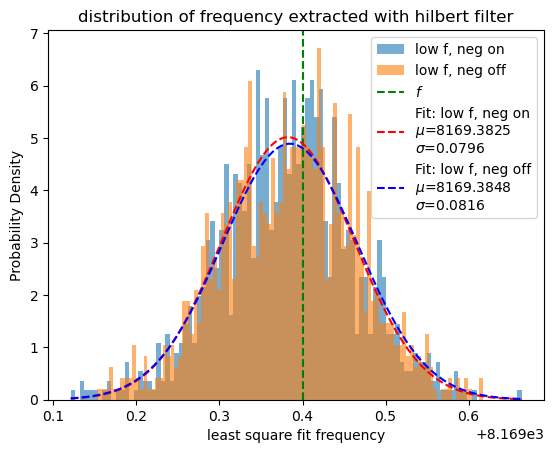

In [ ]:
import scipy.stats as stats

# plot the dstrbution
plt.hist(f_lowf_negon_hf_l, bins=100, alpha=0.6, label="low f, neg on", density=True)
plt.hist(f_lowf_negoff_hf_l, bins=100, alpha=0.6, label="low f, neg off", density=True)

# fitting it to anormal distribution
mu_negon, std_negon = stats.norm.fit(f_lowf_negon_hf_l)
mu_negoff, std_negoff = stats.norm.fit(f_lowf_negoff_hf_l)

xmin = min(min(f_lowf_negon_hf_l), min(f_lowf_negoff_hf_l))
xmax = max(max(f_lowf_negon_hf_l), max(f_lowf_negoff_hf_l))
x = np.linspace(xmin, xmax, 1000)
# correct value
plt.axvline(x=w1 / 2 / np.pi, color="g", linestyle="--", label=r"$f$")
plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: low f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: low f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of frequency extracted with hilbert filter")
plt.xlabel("least square fit frequency")
plt.ylabel("Probability Density")
plt.legend()

*high freq trail*

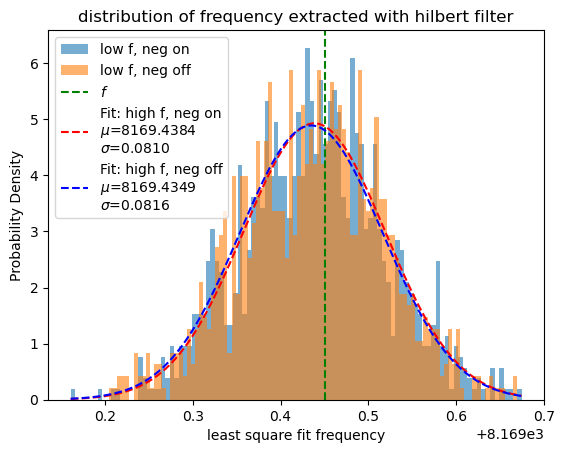

In [ ]:
import scipy.stats as stats

# plot the dstrbution
plt.hist(f_highf_negon_hf_l, bins=100, alpha=0.6, label="high f, neg on", density=True)
plt.hist(
    f_highf_negoff_hf_l, bins=100, alpha=0.6, label="high f, neg off", density=True
)

mu_negon, std_negon = stats.norm.fit(f_highf_negon_hf_l)
mu_negoff, std_negoff = stats.norm.fit(f_highf_negoff_hf_l)

xmin = min(min(f_highf_negon_hf_l), min(f_highf_negoff_hf_l))
xmax = max(max(f_highf_negon_hf_l), max(f_highf_negoff_hf_l))
x = np.linspace(xmin, xmax, 1000)
plt.axvline(x=w2 / 2 / np.pi, color="g", linestyle="--", label=r"$f$")

plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: high f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: high f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of frequency extracted with hilbert filter")
plt.xlabel("least square fit frequency")
plt.ylabel("Probability Density")
plt.legend()

### scipy least square fit

*low freq* 

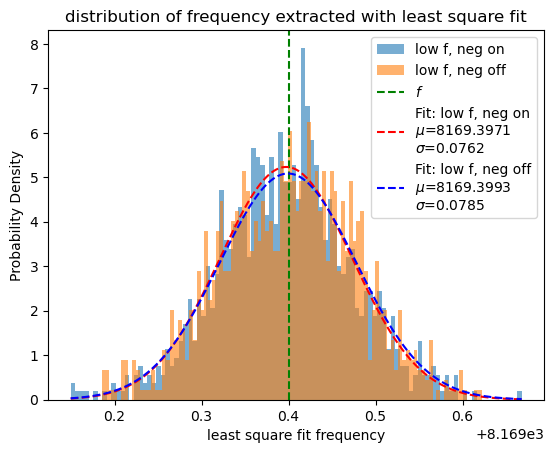

In [ ]:
import scipy.stats as stats


plt.hist(f_lowf_negon_fit_l, bins=100, alpha=0.6, label="low f, neg on", density=True)
plt.hist(f_lowf_negoff_fit_l, bins=100, alpha=0.6, label="low f, neg off", density=True)


mu_negon, std_negon = stats.norm.fit(f_lowf_negon_fit_l)
mu_negoff, std_negoff = stats.norm.fit(f_lowf_negoff_fit_l)


xmin = min(min(f_lowf_negon_fit_l), min(f_lowf_negoff_fit_l))
xmax = max(max(f_lowf_negon_fit_l), max(f_lowf_negoff_fit_l))
x = np.linspace(xmin, xmax, 1000)
plt.axvline(x=w1 / 2 / np.pi, color="g", linestyle="--", label=r"$f$")

plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: low f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: low f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of frequency extracted with least square fit")
plt.xlabel("least square fit frequency")
plt.ylabel("Probability Density")
plt.legend()

*high freq* 

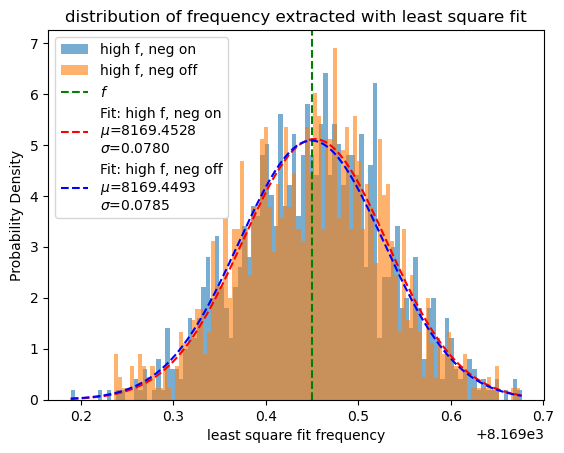

In [ ]:
import scipy.stats as stats


plt.hist(f_highf_negon_fit_l, bins=100, alpha=0.6, label="high f, neg on", density=True)
plt.hist(
    f_highf_negoff_fit_l, bins=100, alpha=0.6, label="high f, neg off", density=True
)


mu_negon, std_negon = stats.norm.fit(f_highf_negon_fit_l)
mu_negoff, std_negoff = stats.norm.fit(f_highf_negoff_fit_l)

xmin = min(min(f_highf_negon_fit_l), min(f_highf_negoff_fit_l))
xmax = max(max(f_highf_negon_fit_l), max(f_highf_negoff_fit_l))
x = np.linspace(xmin, xmax, 1000)
plt.axvline(x=w2 / 2 / np.pi, color="g", linestyle="--", label=r"$f$")

plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: high f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: high f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of frequency extracted with least square fit")
plt.xlabel("least square fit frequency")
plt.ylabel("Probability Density")
plt.legend()

It seems that there is no obvous improvement.

### fit costs

We want to check the costs, it seems that there is also no obvious improvement for costs.

0.00042026280986584525
0.00042671639035271993


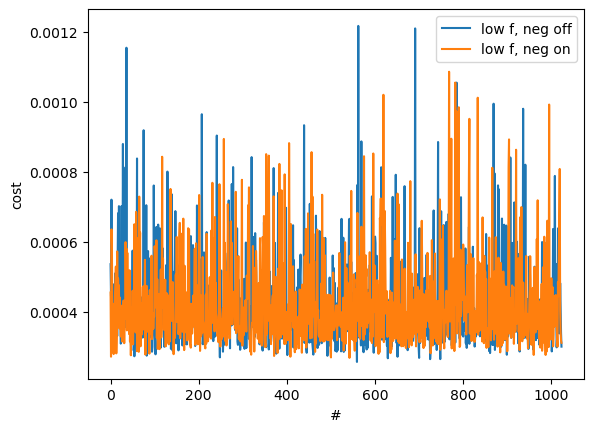

In [ ]:
print(np.mean(np.array(cost_lowf_negoff_fit_l)))
print(np.mean(np.array(cost_lowf_negon_fit_l)))
plt.xlabel("#")
plt.ylabel("cost")
plt.plot(np.array(cost_lowf_negoff_fit_l), label="low f, neg off")
plt.plot(np.array(cost_lowf_negon_fit_l), label="low f, neg on")
plt.legend()

### comparing different methods

We suspect that the noise is dominated by systemic erro, so for the same piece of data, we want to compare the fitting result of 2 different methods.

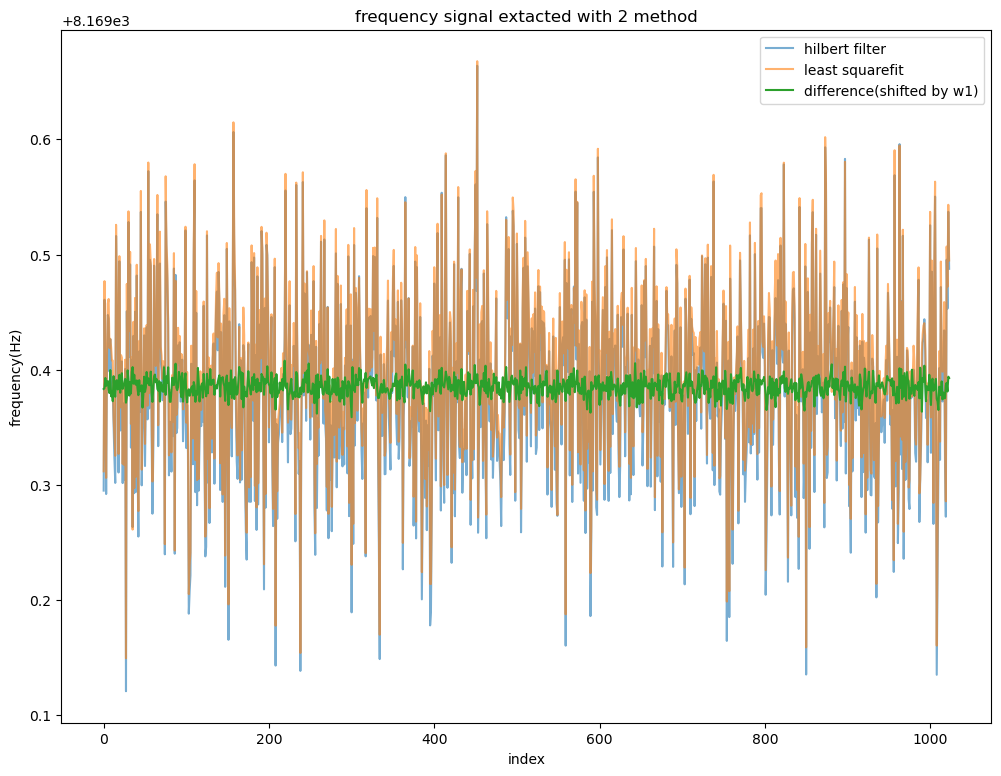

In [ ]:
plt.figure(figsize=(12, 9))
plt.title("frequency signal extacted with 2 method")
plt.xlabel("index")
plt.ylabel("frequency(Hz)")
plt.plot(f_lowf_negon_hf_l, alpha=0.6, label="hilbert filter")
plt.plot(f_lowf_negon_fit_l, alpha=0.6, label="least squarefit")
plt.plot(
    np.array(f_lowf_negon_hf_l) - np.array(f_lowf_negon_fit_l) + w1 / 2 / np.pi,
    label="difference(shifted by w1)",
)
plt.legend()

OK, seems that the result is pretty similar, which means there is no big systemic error(or this 2 methods have similar systemic error).

## x0: amplitude

Then we begin to check other parameters.

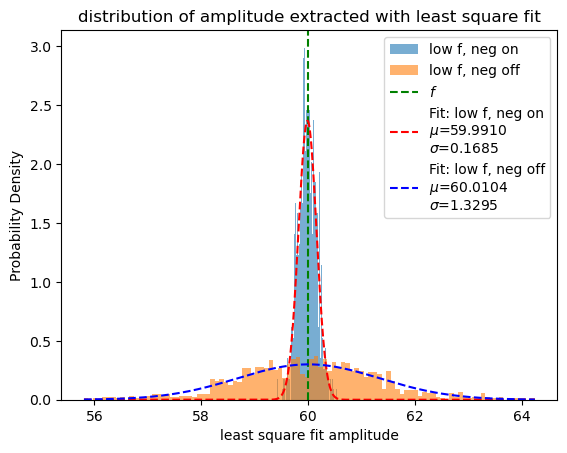

In [ ]:
import scipy.stats as stats

plt.hist(x0_lowf_negon_fit_l, bins=100, alpha=0.6, label="low f, neg on", density=True)
plt.hist(
    x0_lowf_negoff_fit_l, bins=100, alpha=0.6, label="low f, neg off", density=True
)

mu_negon, std_negon = stats.norm.fit(x0_lowf_negon_fit_l)
mu_negoff, std_negoff = stats.norm.fit(x0_lowf_negoff_fit_l)

xmin = min(min(x0_lowf_negon_fit_l), min(x0_lowf_negoff_fit_l))
xmax = max(max(x0_lowf_negon_fit_l), max(x0_lowf_negoff_fit_l))
x = np.linspace(xmin, xmax, 1000)
plt.axvline(x=x0, color="g", linestyle="--", label=r"$f$")

plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: low f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: low f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of amplitude extracted with least square fit")
plt.xlabel("least square fit amplitude")
plt.ylabel("Probability Density")
plt.legend()

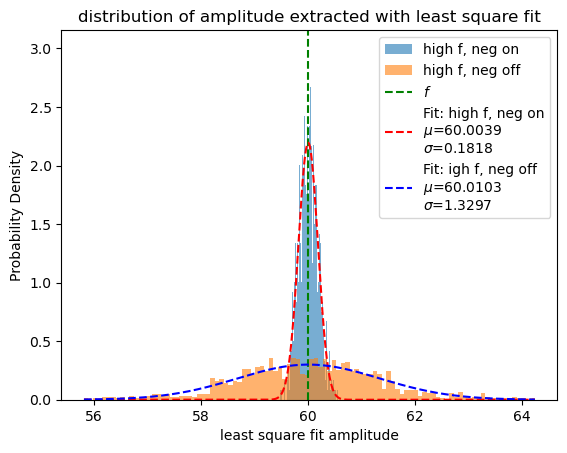

In [ ]:
import scipy.stats as stats


plt.hist(
    x0_highf_negon_fit_l, bins=100, alpha=0.6, label="high f, neg on", density=True
)
plt.hist(
    x0_highf_negoff_fit_l, bins=100, alpha=0.6, label="high f, neg off", density=True
)

mu_negon, std_negon = stats.norm.fit(x0_highf_negon_fit_l)
mu_negoff, std_negoff = stats.norm.fit(x0_highf_negoff_fit_l)

xmin = min(min(x0_highf_negon_fit_l), min(x0_highf_negoff_fit_l))
xmax = max(max(x0_highf_negon_fit_l), max(x0_highf_negoff_fit_l))
x = np.linspace(xmin, xmax, 1000)
plt.axvline(x=x0, color="g", linestyle="--", label=r"$f$")
plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: high f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: igh f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of amplitude extracted with least square fit")
plt.xlabel("least square fit amplitude")
plt.ylabel("Probability Density")
plt.legend()

## phi0: initial phase
 (note that our phase is expressed as (w*t+phase) ), we assume our "real phase" is a straight line.

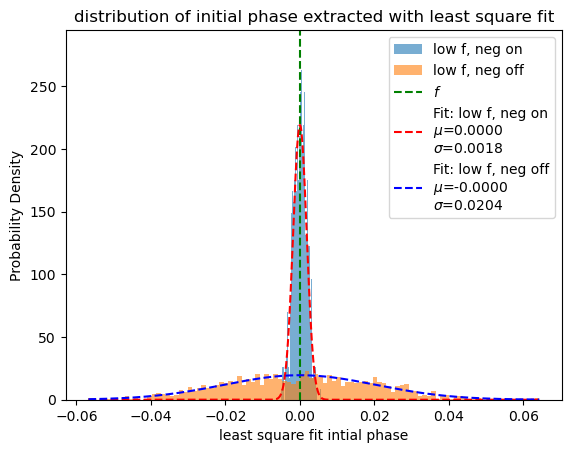

In [ ]:
import scipy.stats as stats

plt.hist(p0_lowf_negon_fit_l, bins=100, alpha=0.6, label="low f, neg on", density=True)
plt.hist(
    p0_lowf_negoff_fit_l, bins=100, alpha=0.6, label="low f, neg off", density=True
)

mu_negon, std_negon = stats.norm.fit(p0_lowf_negon_fit_l)
mu_negoff, std_negoff = stats.norm.fit(p0_lowf_negoff_fit_l)

xmin = min(min(p0_lowf_negon_fit_l), min(p0_lowf_negoff_fit_l))
xmax = max(max(p0_lowf_negon_fit_l), max(p0_lowf_negoff_fit_l))
x = np.linspace(xmin, xmax, 1000)
plt.axvline(x=0, color="g", linestyle="--", label=r"$f$")

plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: low f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: low f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of initial phase extracted with least square fit")
plt.xlabel("least square fit intial phase")
plt.ylabel("Probability Density")
plt.legend()

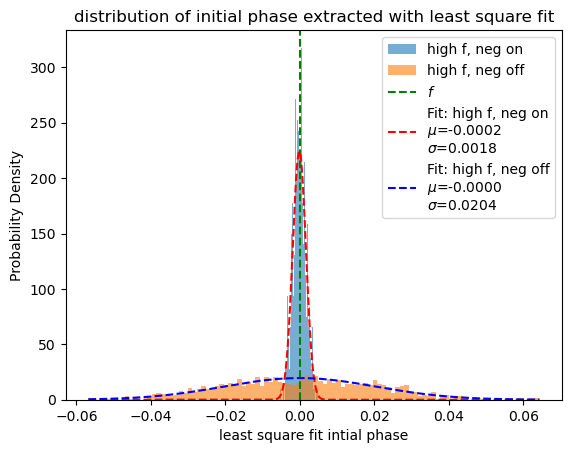

In [ ]:
import scipy.stats as stats

plt.hist(
    p0_highf_negon_fit_l, bins=100, alpha=0.6, label="high f, neg on", density=True
)
plt.hist(
    p0_highf_negoff_fit_l, bins=100, alpha=0.6, label="high f, neg off", density=True
)

mu_negon, std_negon = stats.norm.fit(p0_highf_negon_fit_l)
mu_negoff, std_negoff = stats.norm.fit(p0_highf_negoff_fit_l)

xmin = min(min(p0_highf_negon_fit_l), min(p0_highf_negoff_fit_l))
xmax = max(max(p0_highf_negon_fit_l), max(p0_highf_negoff_fit_l))
x = np.linspace(xmin, xmax, 1000)
plt.axvline(x=0, color="g", linestyle="--", label=r"$f$")

plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: high f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: high f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of initial phase extracted with least square fit")
plt.xlabel("least square fit intial phase")
plt.ylabel("Probability Density")
plt.legend()

So we can conclude that the neg feedback successfully suppress the noise for x0 & phi_0, but it don't suppress the noise of w. This is so inobvious, we have 3 assumptions:

1. The phi_0 and w has high correlation, which introduce systemic noise to the latter distribution.
2. The heating-up behavior of our neg on noise introduce extra frequency noise (the neg feedback can only suppress the amplitude of phase noise, instead of the derivative)

# 4 correlation problem



### setting up function 

We want to calculate the variance and correlation of our parameters, we gonna use Jacobian Matrix to approximate those value.  

In [ ]:
def parameter_uncertainty_from_lsq(res, n_params=None, use_pinv=True):
    """
    Estimate parameter covariance, std, and correlation matrix
    from scipy.optimize.least_squares result.
    """
    J = res.jac  # jacobian
    r = res.fun  # residual

    n_data = J.shape[0]
    if n_params is None:
        n_params = J.shape[1]

    dof = n_data - n_params
    if dof <= 0:
        raise ValueError("Not enough data points to estimate variance.")

    # residual variance estimate
    sigma2 = np.sum(r**2) / dof
    # equivalent: sigma2 = 2 * res.cost / dof

    JTJ = J.T @ J

    if use_pinv:
        JTJ_inv = np.linalg.pinv(JTJ)
    else:
        JTJ_inv = np.linalg.inv(JTJ)

    cov = sigma2 * JTJ_inv

    std = np.sqrt(np.diag(cov))

    corr = cov / np.outer(std, std)

    return cov, std, corr


def fit_many_warmstart_res(
    Y, t, E, V0, p0, bounds=None, loss="huber", x_scale=None, method="dogbox"
):
    """
    This function is used to fit our signal with warm start method, wo cut our signal into small
    pieces, and when we fit it, we want to approx the initial guess for the Ith trail by the
    fitting result of (I-1)th trail, which is called warm start.
    Parameters:
        Y [list of array]: each array is the signal we want to fit, which is a 2D array with the
        first column as the time and the second column as the signal.
        t [array]: the time array of the signal.
        E [array]: the envelope array of the signal.
        V0 [float]: the V0 of the signal.
        p0 [array]: the initial guess of the parameters.
        bounds [tuple]: the bounds of the parameters.
        loss [str]: the loss function we want to use.
        x_scale [array]: the scale of the parameters.
        method [str]: the method we want to use to fit the signal.
    Returns:
        res[class]: the class of fitting outcome
    """
    fun, jac = make_fun_jac(t, E, V0)

    n_seg = len(Y)
    P = np.empty((n_seg, 4), float)
    costs = np.empty(n_seg, float) 
    nfevs = np.empty(n_seg, int)
    p = np.array(p0, float)

    if x_scale is None:
        x_scale = [
            np.max([np.abs(bounds[1][i] - bounds[0][i]), 1e-10])
            for i in range(len(bounds[0]))
        ]

    for i, y in enumerate(Y):
        res = least_squares(
            lambda pp: fun(pp, y),
            x0=p,
            jac=lambda pp: jac(pp, y),
            method=method,
            bounds=bounds if bounds is not None else (-np.inf, np.inf),
            loss=loss,
            x_scale=x_scale,
            max_nfev=50,  
            xtol=1e-15,
            ftol=1e-15,
            gtol=1e-15,
        )

        P[i] = res.x
        if n_seg > 1:
            p = P[i]
            p[1] = (t[-1] + t[1] - t[0]) * P[i][-1] + p[1]
            p[1] = (p[1] + np.pi) % (2 * np.pi) - np.pi  # transfering phase to [-pi,pi]
            p[0] = P[i][0] * E[-1] * E[1] / E[0]
            if bounds is not None:
                bounds[0][0] = bounds[0][0] * E[-1] * E[1] / E[0]
                bounds[1][0] = bounds[1][0] * E[-1] * E[1] / E[0]
        costs[i] = res.cost
        nfevs[i] = res.nfev
    return res

## running fitting to get the cond number

By experience, if our cond number < 1e8, our jacobian matrix gonna be inversable, then we can calculate the td, corr using it.

In [ ]:
# signal parameters
x0 = 60  # initial amplitude (arbitrary scale)

lam = 1314  # wavelength of signal
V0 = 1  # bias voltage

std_shot = 0.0005  # standard deviation for shot noise
rate = 1  # sampling or scaling rate (unused here, but may be part of other logic)
w = w1

# Simulated exponential decay envelope (over-estimating Q to mimic imprecision)
E = np.exp(-t * w0 / (Q + 200) / 2)
t = sig_low[:, 0] + sig_low[1, 0]  # time vector, start not at zero
dt = t[1] - t[0]  # time step


dw = 0.05 * 2 * np.pi  # frequency step (in rad/s)
w1 = 2 * np.pi * 8169.4  # central frequency (in rad/s)
w2 = w1 + dw  # alternative frequency (unused here)
w = w1  # use w1 as the working frequency

pi = 0.5 * np.pi  # constant for π/2

dt_chunk_target = 221e-6  # target duration of each data chunk (seconds)
t_rip = 4.5e-4  # time for ripple/window effect (seconds)

##############

# Result holders for each fitting (negative on/off cases)
res_negon_l = []
res_negoff_l = []

cov_negon_l = []
cov_negoff_l = []

std_negon_l = []
std_negoff_l = []

corr_negon_l = []
corr_negoff_l = []

condn_negon_l = []  # condition numbers for neg-on fits
condn_negoff_l = []  # condition numbers for neg-off fits

# Loop over all noise samples
for i in range(len(noise_0_low_l)):

    print("index = " + str(i))

    amp_sig = 1  # assume starting amplitude is ~constant
    phi0_sig = 0  # initial phase offset
    V_b = 0  # bias voltage, unused here but can be set for future use
    phi_b = 0.001 * np.random.rand()  # small random phase bias
    x0 = 60  # reset amplitude for each trial

    # Extract thermal noise snippets for this trial
    noise_thermal = noise_0_low_l[i][:, 0]
    noise_thermal_negoff = noise_eq[i * len(t) : (i + 1) * len(t), 0]
    noise_shot = np.random.randn(len(t)) * std_shot  # generate new shot noise

    # Generate test signal: neg-on (with thermal noise)
    signal_n0_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E + 1e9 * noise_thermal,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )

    # Generate test signal: neg-off (with different thermal noise)
    signal_negoff_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E + 1e9 * noise_thermal_negoff,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )

    phase_right = w * t + phi0_sig  # correct reference phase

    # Initial parameter guess:
    p0 = [65 / lam * 2 * np.pi, 0, 0, w - 0.005]
    # p: x0, phi0, phiB, w   (guess values for all)
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )

    # Fitting for neg-on data
    res = fit_many_warmstart_res(
        [signal_n0_test],
        t,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    J = res.jac  # Jacobian from fitting result
    JTJ = J.T @ J  # Compute J^T * J
    condn_negon_l.append(np.linalg.cond(JTJ))  # Save condition number

    # Repeat fitting for neg-off data
    p0 = [65 / lam * 2 * np.pi, 0, 0, w - 0.005]
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )
    res = fit_many_warmstart_res(
        [signal_negoff_test],
        t,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    J = res.jac
    JTJ = J.T @ J
    condn_negoff_l.append(np.linalg.cond(JTJ))  # Save condition number

index = 0
index = 1
index = 2
index = 3
index = 4
index = 5
index = 6
index = 7
index = 8
index = 9
index = 10
index = 11
index = 12
index = 13
index = 14
index = 15
index = 16
index = 17
index = 18
index = 19
index = 20
index = 21
index = 22
index = 23
index = 24
index = 25
index = 26
index = 27
index = 28
index = 29
index = 30
index = 31
index = 32
index = 33
index = 34
index = 35
index = 36
index = 37
index = 38
index = 39
index = 40
index = 41
index = 42
index = 43
index = 44
index = 45
index = 46
index = 47
index = 48
index = 49
index = 50
index = 51
index = 52
index = 53
index = 54
index = 55
index = 56
index = 57
index = 58
index = 59
index = 60
index = 61
index = 62
index = 63
index = 64
index = 65
index = 66
index = 67
index = 68
index = 69
index = 70
index = 71
index = 72
index = 73
index = 74
index = 75
index = 76
index = 77
index = 78
index = 79
index = 80
index = 81
index = 82
index = 83
index = 84
index = 85
index = 86
index = 87
index = 88
index = 89
index = 90
index = 9

## cond number

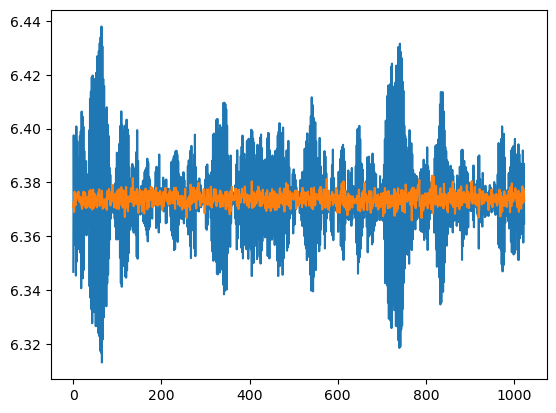

In [ ]:
plt.plot(np.log10(condn_negoff_l))
plt.plot(np.log10(condn_negon_l))

## fitting again to get the std and corr

In [ ]:
# Experiment simulation and fitting with detailed English comments

x0 = 60  # Initial amplitude
lam = 1314  # Wavelength
V0 = 1      # Reference voltage
std_shot = 0.0005  # Standard deviation for shot noise
phi0_sig = 0      # Initial phase offset
V_b = 0           # Bias voltage (not used here)

# Calculate decaying envelope E with intentionally increased Q (simulate poor Q estimation)
E = np.exp(
    -t * w0 / (Q + 200) / 2
)  # Intentionally use a larger Q in E to mimic real-world Q estimation uncertainty

# Prepare time axis: shift so time does not start at zero, but at time step
t = sig_low[:, 0] + sig_low[1, 0]  # Start point is not zero, but dt
dt = t[1] - t[0]  # Calculate time step

# Frequency setup
dw = 0.05 * 2 * np.pi          # Frequency step in rad/s
w1 = 2 * np.pi * 8169.4        # Angular frequency 1 (base)
w2 = w1 + dw                   # Angular frequency 2 (offset)
w = w1                         # Current working angular frequency

pi = 0.5 * np.pi               # Pi/2

dt_chunk_target = 221e-6       # Target chunk duration
t_rip = 4.5e-4                 # Ripple duration

# Initialize result storage lists for "neg-on" and "neg-off" fits
res_negon_l = []
res_negoff_l = []

# Store covariance matrices, standard deviations, and correlation matrices
cov_negon_l = []
cov_negoff_l = []

std_negon_l = []
std_negoff_l = []

corr_negon_l = []
corr_negoff_l = []

# Store condition numbers (for evaluating fit quality/stability)
condn_negon_l = []
condn_negoff_l = []


for i in range(len(noise_0_low_l)):
    w = w1  # Reset working frequency
    print("index = " + str(i))
    std_shot = 0.0005
    amp_sig = 1       # Assume signal amplitude is very constant 
    phi_b = 0.001 * np.random.rand()  # Small random phase bias

    # Extract thermal noise for neg-on and neg-off
    noise_thermal = noise_0_low_l[i][:, 0]
    noise_thermal_negoff = noise_eq[i * len(t):(i + 1) * len(t), 0]
    # Generate shot noise (Gaussian)
    noise_shot = np.random.randn(len(t)) * std_shot

    # Simulated signal (neg-on): with amplitude, noise and exponential decay
    signal_n0_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E + 1e9 * noise_thermal,  # Simulated mechanical signal with thermal noise 
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot  # Additively add shot noise
    )

    # Simulated signal (neg-off): with its own noise realization
    signal_negoff_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E
            + 1e9 * noise_thermal_negoff,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )
    phase_right = w * t + phi0_sig  # Used for reference (not plotted here)

    # Initial guess for [x0, phi0, phiB, w]
    p0 = [
        65 / lam * 2 * np.pi,  # x0 initial guess, scaled and unit-converted
        0,                     # phi0
        0,                     # phiB
        w - 0.005,             # Slightly offset frequency guess
    ]  # We have good estimates for w, phiB, and phi0, but x0,V0 are less certain; let's pretend they're also well-estimated for now

    # Set fitting bounds for [x0, phi0, phiB, w]
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],  # Lower bounds
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],  # Upper bounds
    )
    # Scale each parameter by its allowed range for robust optimization
    x_scale = [np.abs(bounds[1][i] - bounds[0][i]) for i in range(len(bounds[0]))]

    # Fit (neg-on)
    res = fit_many_warmstart_res(
        [signal_n0_test],
        t,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    # Estimate uncertainty in fit parameters (covariance, std, correlation)
    cov, std, corr = parameter_uncertainty_from_lsq(res, n_params=None, use_pinv=False)
    cov_negon_l.append(cov)
    std_negon_l.append(std)
    corr_negon_l.append(corr)

    # Repeat the above for the neg-off case
    p0 = [
        65 / lam * 2 * np.pi,
        0,
        0,
        w - 0.005,
    ]  # Same as before
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )
    x_scale = [np.abs(bounds[1][i] - bounds[0][i]) for i in range(len(bounds[0]))]
    res = fit_many_warmstart_res(
        [signal_negoff_test],
        t,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    cov, std, corr = parameter_uncertainty_from_lsq(res, n_params=None, use_pinv=False)
    cov_negoff_l.append(cov)
    std_negoff_l.append(std)
    corr_negoff_l.append(corr)

index = 0
index = 1
index = 2
index = 3
index = 4
index = 5
index = 6
index = 7
index = 8
index = 9
index = 10
index = 11
index = 12
index = 13
index = 14
index = 15
index = 16
index = 17
index = 18
index = 19
index = 20
index = 21
index = 22
index = 23
index = 24
index = 25
index = 26
index = 27
index = 28
index = 29
index = 30
index = 31
index = 32
index = 33
index = 34
index = 35
index = 36
index = 37
index = 38
index = 39
index = 40
index = 41
index = 42
index = 43
index = 44
index = 45
index = 46
index = 47
index = 48
index = 49
index = 50
index = 51
index = 52
index = 53
index = 54
index = 55
index = 56
index = 57
index = 58
index = 59
index = 60
index = 61
index = 62
index = 63
index = 64
index = 65
index = 66
index = 67
index = 68
index = 69
index = 70
index = 71
index = 72
index = 73
index = 74
index = 75
index = 76
index = 77
index = 78
index = 79
index = 80
index = 81
index = 82
index = 83
index = 84
index = 85
index = 86
index = 87
index = 88
index = 89
index = 90
index = 9

## check the std

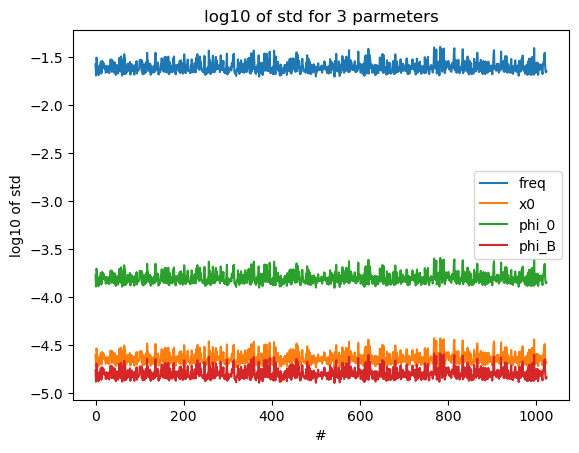

In [ ]:
plt.plot(np.log10(np.array(std_negon_l)[:, -1]), label="freq")
plt.plot(np.log10(np.array(std_negon_l)[:, 0]), label="x0")
plt.plot(np.log10(np.array(std_negon_l)[:, 1]), label="phi_0")
plt.plot(np.log10(np.array(std_negon_l)[:, 2]), label="phi_B")
plt.legend()
plt.xlabel("#")
plt.ylabel("log10 of std")
plt.title("log10 of std for 3 parmeters")
plt.show()

## check the corr

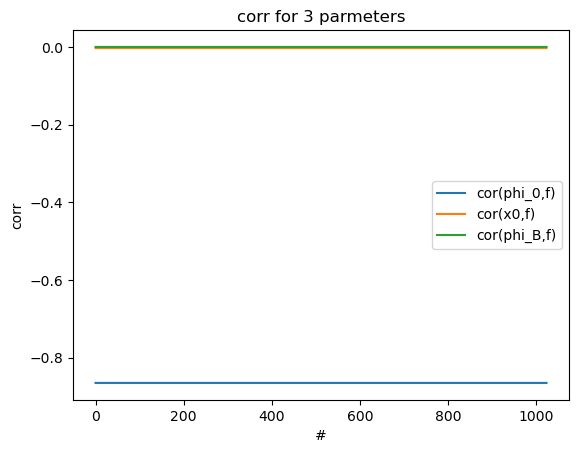

In [ ]:
plt.plot(np.array(corr_negon_l)[:, 1, -1], label="cor(phi_0,f)")
plt.plot(np.array(corr_negon_l)[:, 0, -1], label="cor(x0,f)")
plt.plot(np.array(corr_negon_l)[:, 2, -1], label="cor(phi_B,f)")
plt.legend()
plt.xlabel("#")
plt.ylabel("corr")
plt.title("corr for 3 parmeters")
plt.show()

Notice that the corr(phi_0,f)~-0.8, implying the high correlation of phi_0 and w. This is because our phase looks like $w*t+phi_0$, so our phase has "phase memory", let's try to use the phase in the middle instead. 

## Middle Phase

The solution gonna is quite straight forward: changing our t array from [dt,T] or [-T/2,T/2], then the $phi_0$ in $w*t+phi_0$ gonna be the "middle phase". 

In [ ]:
# Initial parameter values
x0 = 60  # Initial amplitude (position related)
lam = 1314  # Wavelength (nm)
V0 = 1  # Signal amplitude scale (unitless, normalization)
std_shot = 0.0005  # Standard deviation of shot noise
rate = 1  # Sampling rate, not used later

# Calculate exponential decay envelope factor;
# Here we intentionally use a slightly larger Q in E to mimic imperfect Q estimation.
E = np.exp(
    -t * w0 / (Q + 200) / 2
)

# Time axis: time values shifted by one dt step, so the start time is dt instead of 0.
t = sig_low[:, 0] + sig_low[1, 0]
dt = t[1] - t[0]  # Time step

# Frequencies for the signal (angular frequencies)
dw = 0.05 * 2 * np.pi  # Frequency shift in rad/s
w1 = 2 * np.pi * 8169.4  # Central frequency (rad/s)
w2 = w1 + dw  # Upper frequency (not directly used)
w = w1  # Assign working frequency

pi = 0.5 * np.pi  # Precalculate pi/2

# Some chunk sizes (not directly used here)
N1 = 4 * 16
N2 = int(1024 / 2 / 16)

# Target chunk time interval and ripple time, not used later directly
dt_chunk_target = 221e-6
t_rip = 4.5e-4

##############
# Lists to hold results for each repetition/run
res_negon_l = []
res_negoff_l = []

cov_negon_l = []
cov_negoff_l = []

std_negon_l = []
std_negoff_l = []

corr_negon_l = []
corr_negoff_l = []

condn_negon_l = []
condn_negoff_l = []

# For each realization/noise sample, generate signals and fit
for i in range(len(noise_0_low_l)):
    w = w1  # Reset working frequency for each run
    print("index = " + str(i))
    std_shot = 0.0005  # Standard deviation for shot noise (repeat)
    amp_sig = 1  # Assume the amplitude is close to this value each run
    phi0_sig = 0  # Initial phase for the generated signal
    V_b = 0  # Bias voltage (not used)
    phi_b = 0.001 * np.random.rand()  # Tiny random phase offset each run
    x0 = 60  # Amplitude position (repeat)

    # Get thermal noise for negon and negoff cases from precomputed lists
    noise_thermal = noise_0_low_l[i][:, 0]  # Thermal noise for "negon"
    noise_thermal_negoff = noise_eq[i * len(t) : (i + 1) * len(t), 0]  # For "negoff"
    noise_shot = np.random.randn(len(t)) * std_shot  # Generate shot noise

    # Generate "negon" signal: position-to-signal conversion with thermal and shot noise
    signal_n0_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E + 1 * 10**9 * noise_thermal,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )
    # Generate "negoff" signal (different thermal noise)
    signal_negoff_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E
            + 1 * 10**9 * noise_thermal_negoff,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )
    phase_right = w * t + phi0_sig  # True phase for sanity check (not used here)

######################################################################
    # Shift time axis to be centered, to reduce correlation between phase and frequency
    t_shift = t - (t[0] + t[-1]) / 2
######################################################################

    # Initial guesses for parameters (in fit): [x0, phi0, phi_B, w]
    # Good prior estimates for frequency, phiB, phi0. For x0, it's scaled using lam.
    p0 = [
        65 / lam * 2 * np.pi,
        ((w - 0.005) * t[len(t) // 2] + np.pi) % (2 * np.pi) - np.pi,
        0,
        w - 0.005,
    ]
    # Bounds on: [x0, phi0, phiB, w]
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )
    # Relative scales for optimization step size
    x_scale = [np.abs(bounds[1][i] - bounds[0][i]) for i in range(len(bounds[0]))]
    # Fit to "negon" test signal; huber loss to reduce outlier sensitivity, dogbox method
    res = fit_many_warmstart_res(
        [signal_n0_test],
        t_shift,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    # Extract parameter uncertainties and append to results lists
    cov, std, corr = parameter_uncertainty_from_lsq(res, n_params=None, use_pinv=False)
    cov_negon_l.append(cov)
    std_negon_l.append(std)
    corr_negon_l.append(corr)

    # Repeat fit for "negoff" signal with same procedure
    p0 = [
        65 / lam * 2 * np.pi,
        ((w - 0.005) * t[len(t) // 2] + np.pi) % (2 * np.pi) - np.pi,
        0,
        w - 0.005,
    ]
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )
    x_scale = [np.abs(bounds[1][i] - bounds[0][i]) for i in range(len(bounds[0]))]
    res = fit_many_warmstart_res(
        [signal_negoff_test],
        t_shift,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    cov, std, corr = parameter_uncertainty_from_lsq(res, n_params=None, use_pinv=False)
    cov_negoff_l.append(cov)
    std_negoff_l.append(std)
    corr_negoff_l.append(corr)

index = 0
index = 1
index = 2
index = 3
index = 4
index = 5
index = 6
index = 7
index = 8
index = 9
index = 10
index = 11
index = 12
index = 13
index = 14
index = 15
index = 16
index = 17
index = 18
index = 19
index = 20
index = 21
index = 22
index = 23
index = 24
index = 25
index = 26
index = 27
index = 28
index = 29
index = 30
index = 31
index = 32
index = 33
index = 34
index = 35
index = 36
index = 37
index = 38
index = 39
index = 40
index = 41
index = 42
index = 43
index = 44
index = 45
index = 46
index = 47
index = 48
index = 49
index = 50
index = 51
index = 52
index = 53
index = 54
index = 55
index = 56
index = 57
index = 58
index = 59
index = 60
index = 61
index = 62
index = 63
index = 64
index = 65
index = 66
index = 67
index = 68
index = 69
index = 70
index = 71
index = 72
index = 73
index = 74
index = 75
index = 76
index = 77
index = 78
index = 79
index = 80
index = 81
index = 82
index = 83
index = 84
index = 85
index = 86
index = 87
index = 88
index = 89
index = 90
index = 9

### std 

The standard deviations of each parameter refect the noise 

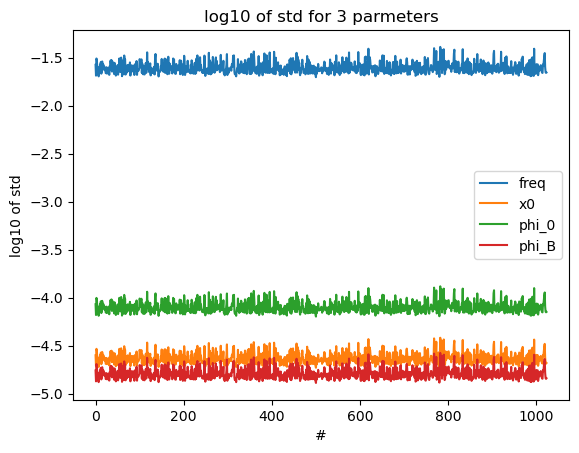

In [ ]:
plt.plot(np.log10(np.array(std_negon_l)[:, -1]), label="freq")
plt.plot(np.log10(np.array(std_negon_l)[:, 0]), label="x0")
plt.plot(np.log10(np.array(std_negon_l)[:, 1]), label="phi_0")
plt.plot(np.log10(np.array(std_negon_l)[:, 2]), label="phi_B")
plt.legend()
plt.xlabel("#")
plt.ylabel("log10 of std")
plt.title("log10 of std for 3 parmeters")
plt.show()

## corr 

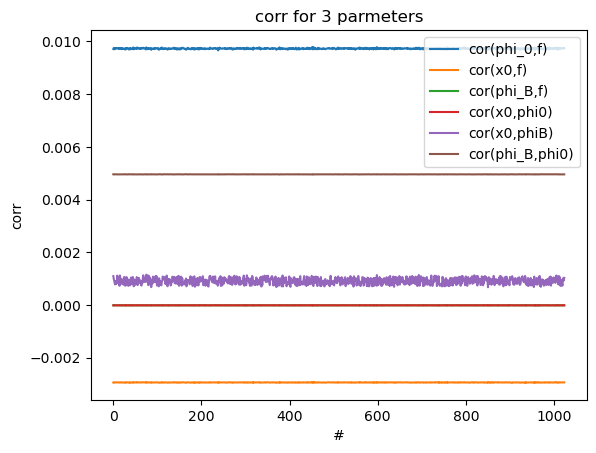

In [ ]:
plt.plot((np.array(corr_negon_l)[:, 1, -1]), label="cor(phi_0,f)")
plt.plot(np.array(corr_negon_l)[:, 0, -1], label="cor(x0,f)")
plt.plot(np.array(corr_negon_l)[:, 2, -1], label="cor(phi_B,f)")
plt.plot(np.array(corr_negon_l)[:, 1, 0], label="cor(x0,phi0)")
plt.plot(np.array(corr_negon_l)[:, 2, 0], label="cor(x0,phiB)")
plt.plot(np.array(corr_negon_l)[:, 2, 1], label="cor(phi_B,phi0)")
plt.legend()
plt.xlabel("#")
plt.ylabel("corr")
plt.title("corr for 3 parmeters")
plt.show()

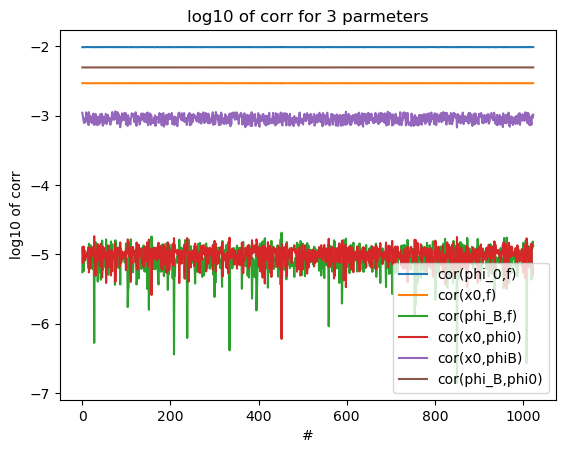

In [ ]:
plt.plot(np.log10(np.abs(np.array(corr_negon_l)[:, 1, -1])), label="cor(phi_0,f)")
plt.plot(np.log10(np.abs(np.array(corr_negon_l)[:, 0, -1])), label="cor(x0,f)")
plt.plot(np.log10(np.abs(np.array(corr_negon_l)[:, 2, -1])), label="cor(phi_B,f)")
plt.plot(np.log10(np.abs(np.array(corr_negon_l)[:, 1, 0])), label="cor(x0,phi0)")
plt.plot(np.log10(np.abs(np.array(corr_negon_l)[:, 2, 0])), label="cor(x0,phiB)")
plt.plot(np.log10(np.abs(np.array(corr_negon_l)[:, 2, 1])), label="cor(phi_B,phi0)")
plt.legend()
plt.xlabel("#")
plt.ylabel("log10 of corr")
plt.title("log10 of corr for 3 parmeters")
plt.show()

### We surely decrease the corr, however, it seems that the std doesn't change. Let's check the parameters


## fitting parameters

In [ ]:
# Initialize parameters
x0 = 60
lam = 1314
V0 = 1
std_shot = 0.0005
phi0_sig = 0
V_b = 0
rate = 1

# Here we intentionally make Q in E a bit larger to simulate the current situation where our Q estimation is not accurate
E = np.exp(
    -t * w0 / (Q + 200) / 2
)

# The starting point is not zero, it is dt
t = sig_low[:, 0] + sig_low[1, 0]
dt = t[1] - t[0]

# Frequency setup
dw = 0.05 * 2 * np.pi
w1 = 2 * np.pi * 8169.4
w2 = w1 + dw
w = w1

pi = 0.5 * np.pi

N1 = 4 * 16
N2 = int(1024 / 2 / 16)

dt_chunk_target = 221e-6
t_rip = 4.5e-4

# Lists for storing fitting and simulated results
x0_lowf_negon_hf_l = []
x0_lowf_negoff_hf_l = []
x0_lowf_negon_fit_l = []
x0_lowf_negoff_fit_l = []

p0_lowf_negon_hf_l = []
p0_lowf_negoff_hf_l = []
p0_lowf_negon_fit_l = []
p0_lowf_negoff_fit_l = []

f_lowf_negon_hf_l = []
f_lowf_negoff_hf_l = []
f_lowf_negon_fit_l = []
f_lowf_negoff_fit_l = []

cost_lowf_negon_fit_l = []
cost_lowf_negoff_fit_l = []

x0_highf_negon_hf_l = []
x0_highf_negoff_hf_l = []
x0_highf_negon_fit_l = []
x0_highf_negoff_fit_l = []

p0_highf_negon_hf_l = []
p0_highf_negoff_hf_l = []
p0_highf_negon_fit_l = []
p0_highf_negoff_fit_l = []

f_highf_negon_hf_l = []
f_highf_negoff_hf_l = []
f_highf_negon_fit_l = []
f_highf_negoff_fit_l = []

cost_highf_negon_fit_l = []
cost_highf_negoff_fit_l = []

for i in range(len(noise_0_low_l)):
    w = w1
    print("index = " + str(i))
    std_shot = 0.0005
    amp_sig = 1  # We assume that our starting amplitude stays at a very close state
    phi_b = 0.001 * np.random.rand()

    # Thermal and shot noise
    noise_thermal = noise_0_low_l[i][:, 0]
    noise_thermal_negoff = noise_eq[i * len(t) : (i + 1) * len(t), 0]
    noise_shot = np.random.randn(len(t)) * std_shot

    # Generate the test signals with and without applied negative feedback
    signal_n0_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E + 1 * 10**9 * noise_thermal,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )
    signal_negoff_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E
            + 1 * 10**9 * noise_thermal_negoff,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )
    phase_right = w * t + phi0_sig

    t_shift = t - (t[0] + t[-1]) / 2

    # Initial fitting parameter guess for lower frequency, neg on
    p0 = [
        65 / lam * 2 * np.pi,
        ((w - 0.005) * t[len(t) // 2] + np.pi) % (2 * np.pi) - np.pi,
        0,
        w - 0.005,
    ]
    # p: x0, phi0, phiB, w
    # For w, phiB, phi0 we can have a good estimation, but for V0 and x0, we're not sure, so we pretend our estimation is good
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )

    P, costs, nfevs = fit_many_warmstart(
        [signal_n0_test],
        t_shift,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    # Store results for low frequency, neg on
    x0_lowf_negon_fit_l.append(P[0, 0] * lam / 2 / np.pi)
    p0_lowf_negon_fit_l.append(
        (P[0, 1] + t_shift[0] * P[0, -1] + np.pi) % (2 * np.pi) - np.pi
    )
    f_lowf_negon_fit_l.append(P[0, -1] / 2 / np.pi)
    cost_lowf_negon_fit_l.append(costs)

    # Initial parameter and fit for lower frequency, neg off
    p0 = [
        65 / lam * 2 * np.pi,
        ((w - 0.005) * t[len(t) // 2] + np.pi) % (2 * np.pi) - np.pi,
        0,
        w - 0.005,
    ]
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )
    P, costs, nfevs = fit_many_warmstart(
        [signal_negoff_test],
        t_shift,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    # Store results for low frequency, neg off
    x0_lowf_negoff_fit_l.append(P[0, 0] * lam / 2 / np.pi)
    p0_lowf_negoff_fit_l.append(
        (P[0, 1] + t_shift[0] * P[0, -1] + np.pi) % (2 * np.pi) - np.pi
    )
    f_lowf_negoff_fit_l.append(P[0, -1] / 2 / np.pi)
    cost_lowf_negoff_fit_l.append(costs)

    ###################################################################
    # Switch to higher frequency
    w = w2

    # Generate thermal noise for the high frequency for this iteration
    noise_thermal = noise_0_high_l[i][:, 0]

    # Generate the test signals at high frequency
    signal_n0_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E + 1 * 10**9 * noise_thermal,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )
    signal_negoff_test = (
        pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * E
            + 1 * 10**9 * noise_thermal_negoff,
            V0,
            lam,
            phi_b=phi_b,
            V_bias=0,
        )
        + noise_shot
    )
    phase_right = w * t + phi0_sig

    p0 = [
        65 / lam * 2 * np.pi,
        ((w - 0.005) * t[len(t) // 2] + np.pi) % (2 * np.pi) - np.pi,
        0,
        w - 0.005,
    ]
    # p: x0, phi0, phiB, w
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )

    P, costs, nfevs = fit_many_warmstart(
        [signal_n0_test],
        t_shift,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    # Store results for high frequency, neg on
    x0_highf_negon_fit_l.append(P[0, 0] * lam / 2 / np.pi)
    p0_highf_negon_fit_l.append(
        (P[0, 1] + t_shift[0] * P[0, -1] + np.pi) % (2 * np.pi) - np.pi
    )
    f_highf_negon_fit_l.append(P[0, -1] / 2 / np.pi)
    cost_highf_negon_fit_l.append(costs)

    # Fit for high frequency, neg off
    p0 = [
        65 / lam * 2 * np.pi,
        ((w - 0.005) * t[len(t) // 2] + np.pi) % (2 * np.pi) - np.pi,
        0,
        w - 0.005,
    ]
    bounds = (
        [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
        [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
    )
    P, costs, nfevs = fit_many_warmstart(
        [signal_negoff_test],
        t_shift,
        E,
        V0,
        p0,
        bounds=bounds,
        loss="huber",
        x_scale=x_scale,
        method="dogbox",
    )
    # Store results for high frequency, neg off
    x0_highf_negoff_fit_l.append(P[0, 0] * lam / 2 / np.pi)
    p0_highf_negoff_fit_l.append(
        (P[0, 1] + t_shift[0] * P[0, -1] + np.pi) % (2 * np.pi) - np.pi
    )
    f_highf_negoff_fit_l.append(P[0, -1] / 2 / np.pi)
    cost_highf_negoff_fit_l.append(costs)

index = 0
index = 1
index = 2
index = 3
index = 4
index = 5
index = 6
index = 7
index = 8
index = 9
index = 10
index = 11
index = 12
index = 13
index = 14
index = 15
index = 16
index = 17
index = 18
index = 19
index = 20
index = 21
index = 22
index = 23
index = 24
index = 25
index = 26
index = 27
index = 28
index = 29
index = 30
index = 31
index = 32
index = 33
index = 34
index = 35
index = 36
index = 37
index = 38
index = 39
index = 40
index = 41
index = 42
index = 43
index = 44
index = 45
index = 46
index = 47
index = 48
index = 49
index = 50
index = 51
index = 52
index = 53
index = 54
index = 55
index = 56
index = 57
index = 58
index = 59
index = 60
index = 61
index = 62
index = 63
index = 64
index = 65
index = 66
index = 67
index = 68
index = 69
index = 70
index = 71
index = 72
index = 73
index = 74
index = 75
index = 76
index = 77
index = 78
index = 79
index = 80
index = 81
index = 82
index = 83
index = 84
index = 85
index = 86
index = 87
index = 88
index = 89
index = 90
index = 9

## freq

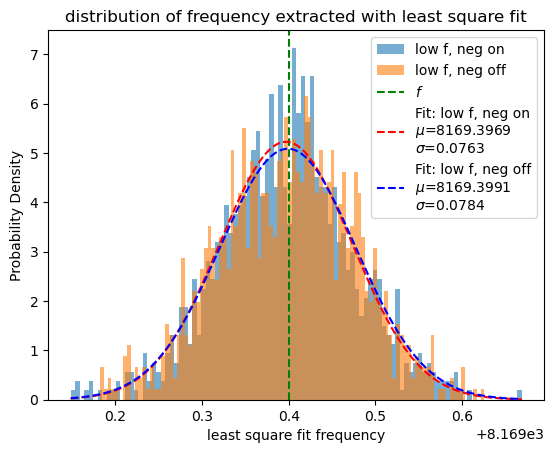

In [ ]:
import scipy.stats as stats

# Plot histograms of the frequency results
plt.hist(f_lowf_negon_fit_l, bins=100, alpha=0.6, label="low f, neg on", density=True)
plt.hist(f_lowf_negoff_fit_l, bins=100, alpha=0.6, label="low f, neg off", density=True)

# Fit Gaussian (normal) distributions to the data
mu_negon, std_negon = stats.norm.fit(f_lowf_negon_fit_l)
mu_negoff, std_negoff = stats.norm.fit(f_lowf_negoff_fit_l)

# Generate x values for plotting the fitted curves
xmin = min(min(f_lowf_negon_fit_l), min(f_lowf_negoff_fit_l))
xmax = max(max(f_lowf_negon_fit_l), max(f_lowf_negoff_fit_l))
x = np.linspace(xmin, xmax, 1000)
plt.axvline(x=w1 / 2 / np.pi, color="g", linestyle="--", label=r"$f$")

# Plot the fitted Gaussian distribution curves
plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: low f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: low f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of frequency extracted with least square fit")
plt.xlabel("least square fit frequency")
plt.ylabel("Probability Density")
plt.legend()

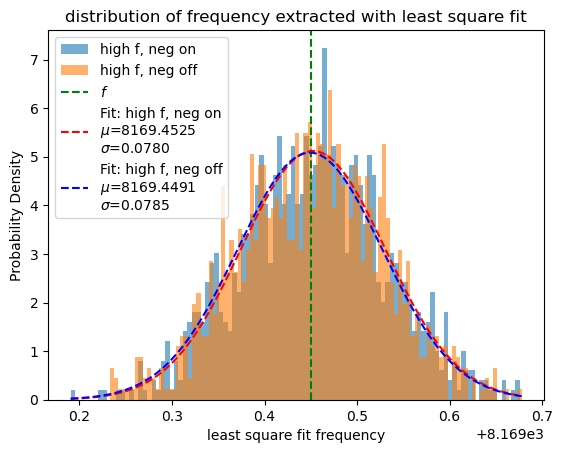

In [ ]:
import scipy.stats as stats

# Plot histogram of the high frequency results
plt.hist(f_highf_negon_fit_l, bins=100, alpha=0.6, label="high f, neg on", density=True)
plt.hist(
    f_highf_negoff_fit_l, bins=100, alpha=0.6, label="high f, neg off", density=True
)

# Fit Gaussian (normal) distributions to the data
mu_negon, std_negon = stats.norm.fit(f_highf_negon_fit_l)
mu_negoff, std_negoff = stats.norm.fit(f_highf_negoff_fit_l)

# Generate x values for plotting the fitted curves
xmin = min(min(f_highf_negon_fit_l), min(f_highf_negoff_fit_l))
xmax = max(max(f_highf_negon_fit_l), max(f_highf_negoff_fit_l))
x = np.linspace(xmin, xmax, 1000)
plt.axvline(x=w2 / 2 / np.pi, color="g", linestyle="--", label=r"$f$")

# Plot the fitted Gaussian distribution curves
plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: high f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: high f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of frequency extracted with least square fit")
plt.xlabel("least square fit frequency")
plt.ylabel("Probability Density")
plt.legend()

## phase

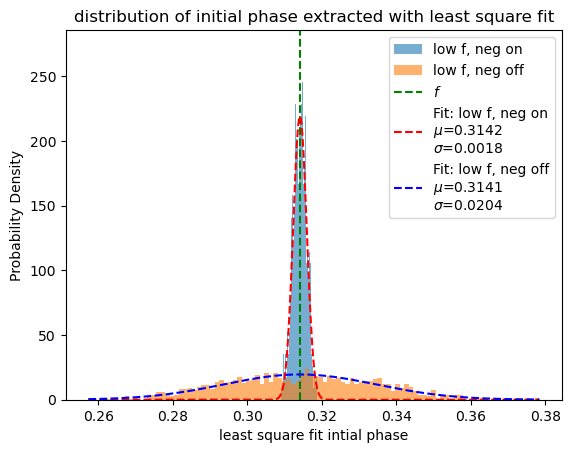

In [ ]:
import scipy.stats as stats

plt.hist(p0_lowf_negon_fit_l, bins=100, alpha=0.6, label="low f, neg on", density=True)
plt.hist(
    p0_lowf_negoff_fit_l, bins=100, alpha=0.6, label="low f, neg off", density=True
)

mu_negon, std_negon = stats.norm.fit(p0_lowf_negon_fit_l)
mu_negoff, std_negoff = stats.norm.fit(p0_lowf_negoff_fit_l)

xmin = min(min(p0_lowf_negon_fit_l), min(p0_lowf_negoff_fit_l))
xmax = max(max(p0_lowf_negon_fit_l), max(p0_lowf_negoff_fit_l))
x = np.linspace(xmin, xmax, 1000)
plt.axvline(x=w1 * t[0], color="g", linestyle="--", label=r"$f$")

plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: low f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: low f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of initial phase extracted with least square fit")
plt.xlabel("least square fit intial phase")
plt.ylabel("Probability Density")
plt.legend()

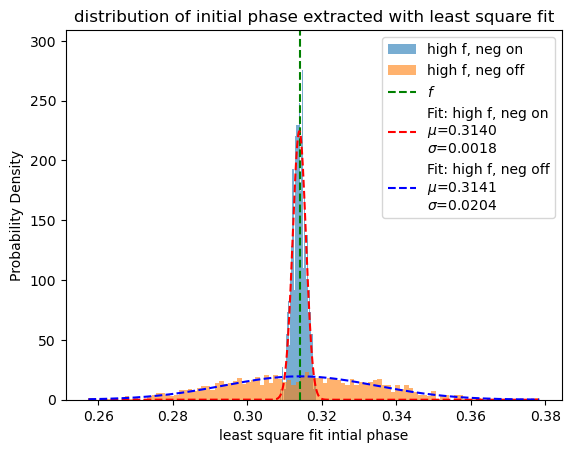

In [ ]:
import scipy.stats as stats

plt.hist(
    p0_highf_negon_fit_l, bins=100, alpha=0.6, label="high f, neg on", density=True
)
plt.hist(
    p0_highf_negoff_fit_l, bins=100, alpha=0.6, label="high f, neg off", density=True
)

mu_negon, std_negon = stats.norm.fit(p0_highf_negon_fit_l)
mu_negoff, std_negoff = stats.norm.fit(p0_highf_negoff_fit_l)

xmin = min(min(p0_highf_negon_fit_l), min(p0_highf_negoff_fit_l))
xmax = max(max(p0_highf_negon_fit_l), max(p0_highf_negoff_fit_l))
x = np.linspace(xmin, xmax, 1000)
plt.axvline(x=w1 * t[0], color="g", linestyle="--", label=r"$f$")

plt.plot(
    x,
    stats.norm.pdf(x, mu_negon, std_negon),
    "r--",
    label=f"Fit: high f, neg on\n$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
)
plt.plot(
    x,
    stats.norm.pdf(x, mu_negoff, std_negoff),
    "b--",
    label=f"Fit: high f, neg off\n$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
)
plt.title("distribution of initial phase extracted with least square fit")
plt.xlabel("least square fit intial phase")
plt.ylabel("Probability Density")
plt.legend()

## costs

0.00042059850434396676
0.0004260308358171978


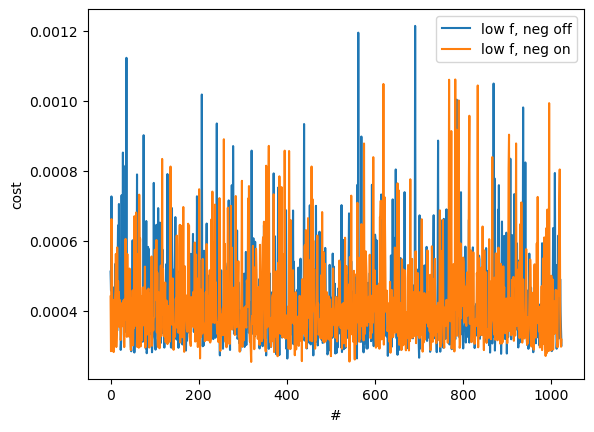

In [ ]:
print(np.mean(np.array(cost_lowf_negoff_fit_l)))
print(np.mean(np.array(cost_lowf_negon_fit_l)))
plt.xlabel("#")
plt.ylabel("cost")
plt.plot(np.array(cost_lowf_negoff_fit_l), label="low f, neg off")
plt.plot(np.array(cost_lowf_negon_fit_l), label="low f, neg on")
plt.legend()

We still don't see a big improvement, so the main problem is not the correlaton.

# 5 pattern problem

We suspect that our noise's heating-up pattern introduce extra freq noise. So we deicded to mannually adjust the amplitude of our signals(by multiplying our signal with a factor). We varied our factor from 0.1 to 5, then check the distribution of our parameters.

In [ ]:
x0 = 60  # initial amplitude
lam = 1314  # wavelength
V0 = 1      # reference voltage
std_shot = 0.0005  # standard deviation for shot noise
rate = 1           # sampling rate (not used below)
phi0_sig = 0  # Assume initial phase is 0
V_b = 0      # No bias voltage applied

E = np.exp(
    -t * w0 / (Q + 200) / 2
)  # Here we intentionally use a slightly larger Q in E to simulate our current situation where Q is estimated inaccurately.

t = sig_low[:, 0] + sig_low[1, 0]  # The initial time does not start at 0, it starts at dt
dt = t[1] - t[0]  # time step

dw = 0.05 * 2 * np.pi  # frequency offset for test
w1 = 2 * np.pi * 8169.4  # main angular frequency
w2 = w1 + dw             # test angular frequency
w = w1                   # default working frequency

pi = 0.5 * np.pi  # pi/2 phase

N1 = 4 * 16
N2 = int(1024 / 2 / 16)

dt_chunk_target = 221e-6  # analysis chunk time target
t_rip = 4.5e-4            # rip time for analysis

scaliingfac_l = [0.01, 0.1, 1, 5]  # list of scaling factors for noise

# Preallocate results arrays for storing data-fits at each noise level
x0_lowf_negon_hf_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))
x0_lowf_negoff_hf_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))
x0_lowf_negon_fit_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))
x0_lowf_negoff_fit_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))

p0_lowf_negon_hf_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))
p0_lowf_negoff_hf_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))
p0_lowf_negon_fit_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))
p0_lowf_negoff_fit_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))

f_lowf_negon_hf_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))
f_lowf_negoff_hf_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))
f_lowf_negon_fit_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))
f_lowf_negoff_fit_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))

cost_lowf_negon_fit_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))
cost_lowf_negoff_fit_l = np.zeros((len(scaliingfac_l), len(noise_0_low_l)))

# Loop over all scaling factors and noise realizations
for j in range(len(scaliingfac_l)):
    for i in range(len(noise_0_low_l)):
        w = w1  # use the main angular frequency for each trial
        print("s index=" + str(j) + " index = " + str(i))
        std_shot = 0.0005
        amp_sig = 1  # Assume initial amplitude remains at an almost constant value
        phi_b = 0.001 * np.random.rand()  # Small random phase offset to bias

        t_shift = t - (t[0] + t[-1]) / 2  # Center the time array for fitting

        # Apply scaling to simulate different levels of thermal noise for 'neg on' and 'neg off'
        noise_thermal = noise_0_low_l[i][:, 0] * scaliingfac_l[j]
        noise_thermal_negoff = (
            noise_eq[i * len(t) : (i + 1) * len(t), 0] * scaliingfac_l[j]
        )
        noise_shot = np.random.randn(len(t)) * std_shot  # Generate shot noise

        # Simulate 'negative feedback on' signal
        signal_n0_test = (
            pos2sig(
                amp_sig * x0 * np.cos(w * t + phi0_sig) * E + 1 * 10**9 * noise_thermal,
                V0,
                lam,
                phi_b=phi_b,
                V_bias=0,
            )
            + noise_shot
        )
        # Simulate 'negative feedback off' signal
        signal_negoff_test = (
            pos2sig(
                amp_sig * x0 * np.cos(w * t + phi0_sig) * E
                + 1 * 10**9 * noise_thermal_negoff,
                V0,
                lam,
                phi_b=phi_b,
                V_bias=0,
            )
            + noise_shot
        )
        phase_right = w * t + phi0_sig  # true phase

        # Initial guess for fitting parameters: [x0, phi0, phiB, w]
        p0 = [
            65 / lam * 2 * np.pi,
            0,
            0,
            w - 0.005,
        ]  # We can estimate w, phiB, phi0 well, but not sure about V0 and x0; Assume estimates are good for now

        # Setting parameter bounds for the fitting
        bounds = (
            [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
            [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
        )

        # Fit 'neg on' signal using warmstart fitting
        P, costs, nfevs = fit_many_warmstart(
            [signal_n0_test],
            t,
            E,
            V0,
            p0,
            bounds=bounds,
            loss="huber",
            x_scale=x_scale,
            method="dogbox",
        )
        x0_lowf_negon_fit_l[j, i] = P[0, 0] * lam / 2 / np.pi  # fitted amplitude
        p0_lowf_negon_fit_l[j, i] = (P[0, 1] + t_shift[0] * P[0, -1] + np.pi) % (
            2 * np.pi
        ) - np.pi  # fitted initial phase, wrapped to [-π, π]
        f_lowf_negon_fit_l[j, i] = P[0, -1] / 2 / np.pi        # fitted frequency
        cost_lowf_negon_fit_l[j, i] = costs                    # fitting error/cost

        # Repeat for 'neg off' signal
        p0 = [
            65 / lam * 2 * np.pi,
            0,
            0,
            w - 0.005,
        ]
        bounds = (
            [x0 * 0.5 / lam * 2 * np.pi, -np.pi, -np.pi * 0.005, w - 100],
            [x0 * 1.5 / lam * 2 * np.pi, +np.pi, +np.pi * 0.005, w + 100],
        )
        P, costs, nfevs = fit_many_warmstart(
            [signal_negoff_test],
            t,
            E,
            V0,
            p0,
            bounds=bounds,
            loss="huber",
            x_scale=x_scale,
            method="dogbox",
        )
        x0_lowf_negoff_fit_l[j, i] = P[0, 0] * lam / 2 / np.pi  # fitted amplitude
        p0_lowf_negoff_fit_l[j, i] = (P[0, 1] + t_shift[0] * P[0, -1] + np.pi) % (
            2 * np.pi
        ) - np.pi  # fitted initial phase, wrapped to [-π, π]
        f_lowf_negoff_fit_l[j, i] = P[0, -1] / 2 / np.pi        # fitted frequency
        cost_lowf_negoff_fit_l[j, i] = costs                    # fitting error/cost

        # Frequency extraction via Hilbert filter ('neg off')
        f_lowf_negoff_hf_l[j, i] = getCantileverFreq(
            np.array([t, signal_negoff_test]).T,
            t_cycle=1e-4,
            t_rip=t_rip,
            dt_chunk_target=(t[-1] - t[0] - t_rip * 2),
            bpstyle="gaussian",
        )
        # Frequency extraction via Hilbert filter ('neg on')
        f_lowf_negon_hf_l[j, i] = getCantileverFreq(
            np.array([t, signal_n0_test]).T,
            t_cycle=1e-4,
            t_rip=t_rip,
            dt_chunk_target=(t[-1] - t[0] - t_rip * 2),
            bpstyle="gaussian",
        )

index = 0
index = 1
index = 2
index = 3
index = 4
index = 5
index = 6
index = 7
index = 8
index = 9
index = 10
index = 11
index = 12
index = 13
index = 14
index = 15


C:\Users\top_c\AppData\Local\Temp\ipykernel_23424\3715974195.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cost_lowf_negon_fit_l[j,i]=(costs)
C:\Users\top_c\AppData\Local\Temp\ipykernel_23424\3715974195.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cost_lowf_negoff_fit_l[j,i]=(costs)


index = 16
index = 17
index = 18
index = 19
index = 20
index = 21
index = 22
index = 23
index = 24
index = 25
index = 26
index = 27
index = 28
index = 29
index = 30
index = 31
index = 32
index = 33
index = 34
index = 35
index = 36
index = 37
index = 38
index = 39
index = 40
index = 41
index = 42
index = 43
index = 44
index = 45
index = 46
index = 47
index = 48
index = 49
index = 50
index = 51
index = 52
index = 53
index = 54
index = 55
index = 56
index = 57
index = 58
index = 59
index = 60
index = 61
index = 62
index = 63
index = 64
index = 65
index = 66
index = 67
index = 68
index = 69
index = 70
index = 71
index = 72
index = 73
index = 74
index = 75
index = 76
index = 77
index = 78
index = 79
index = 80
index = 81
index = 82
index = 83
index = 84
index = 85
index = 86
index = 87
index = 88
index = 89
index = 90
index = 91
index = 92
index = 93
index = 94
index = 95
index = 96
index = 97
index = 98
index = 99
index = 100
index = 101
index = 102
index = 103
index = 104
index = 105
inde

# negoff, f

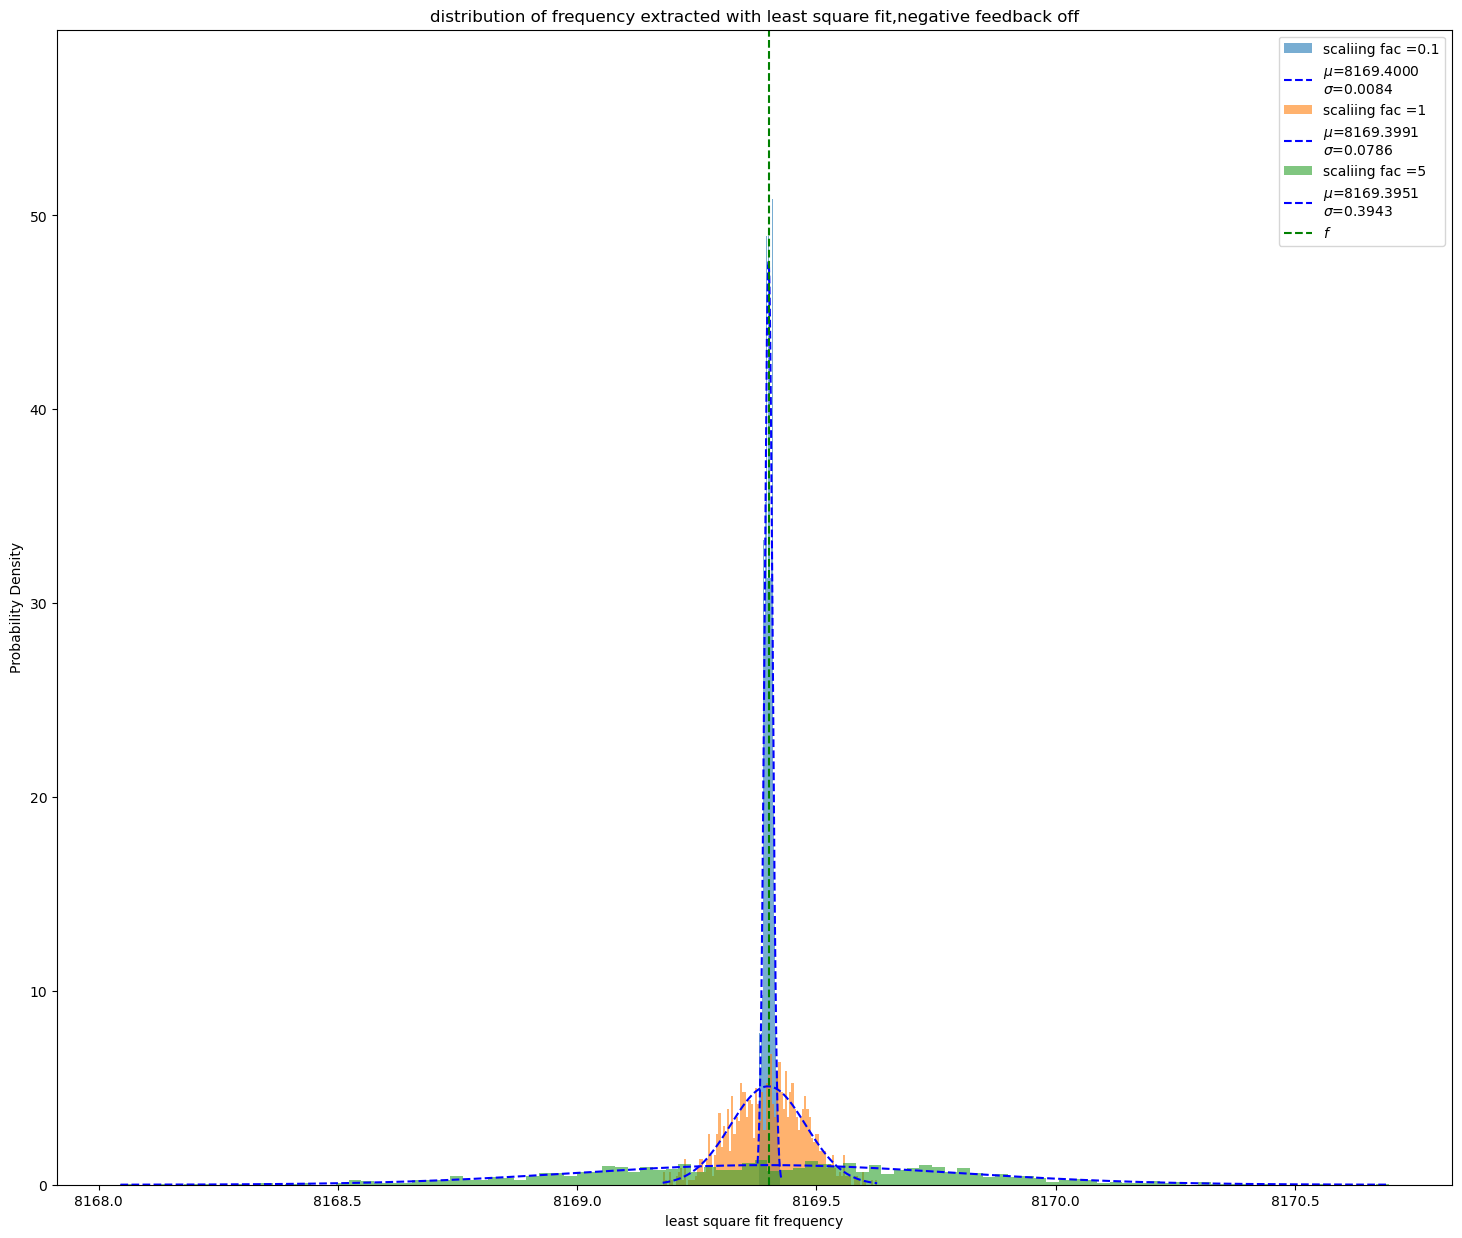

In [ ]:
import scipy.stats as stats

# Plot the histogram
plt.figure(figsize=(18, 15))

for i in [1, 2, 3]:
    plt.hist(
        f_lowf_negoff_fit_l[i],
        bins=100,
        alpha=0.6,
        label="scaliing fac =" + str(scaliingfac_l[i]),
        density=True,
    )

    # Fit a normal distribution to the data
    mu_negoff, std_negoff = stats.norm.fit(f_lowf_negoff_fit_l[i])

    # Generate x values for fitting curve
    xmin = min(f_lowf_negoff_fit_l[i])
    xmax = max(f_lowf_negoff_fit_l[i])
    x = np.linspace(xmin, xmax, 1000)

    # Plot the fitted normal distribution curve
    plt.plot(
        x,
        stats.norm.pdf(x, mu_negoff, std_negoff),
        "b--",
        label=f"$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
    )
plt.axvline(x=w1 / 2 / np.pi, color="g", linestyle="--", label=r"$f$")
plt.title(
    "Distribution of frequency extracted with least square fit, negative feedback off"
)
plt.xlabel("Least square fit frequency")
plt.ylabel("Probability Density")
plt.legend()

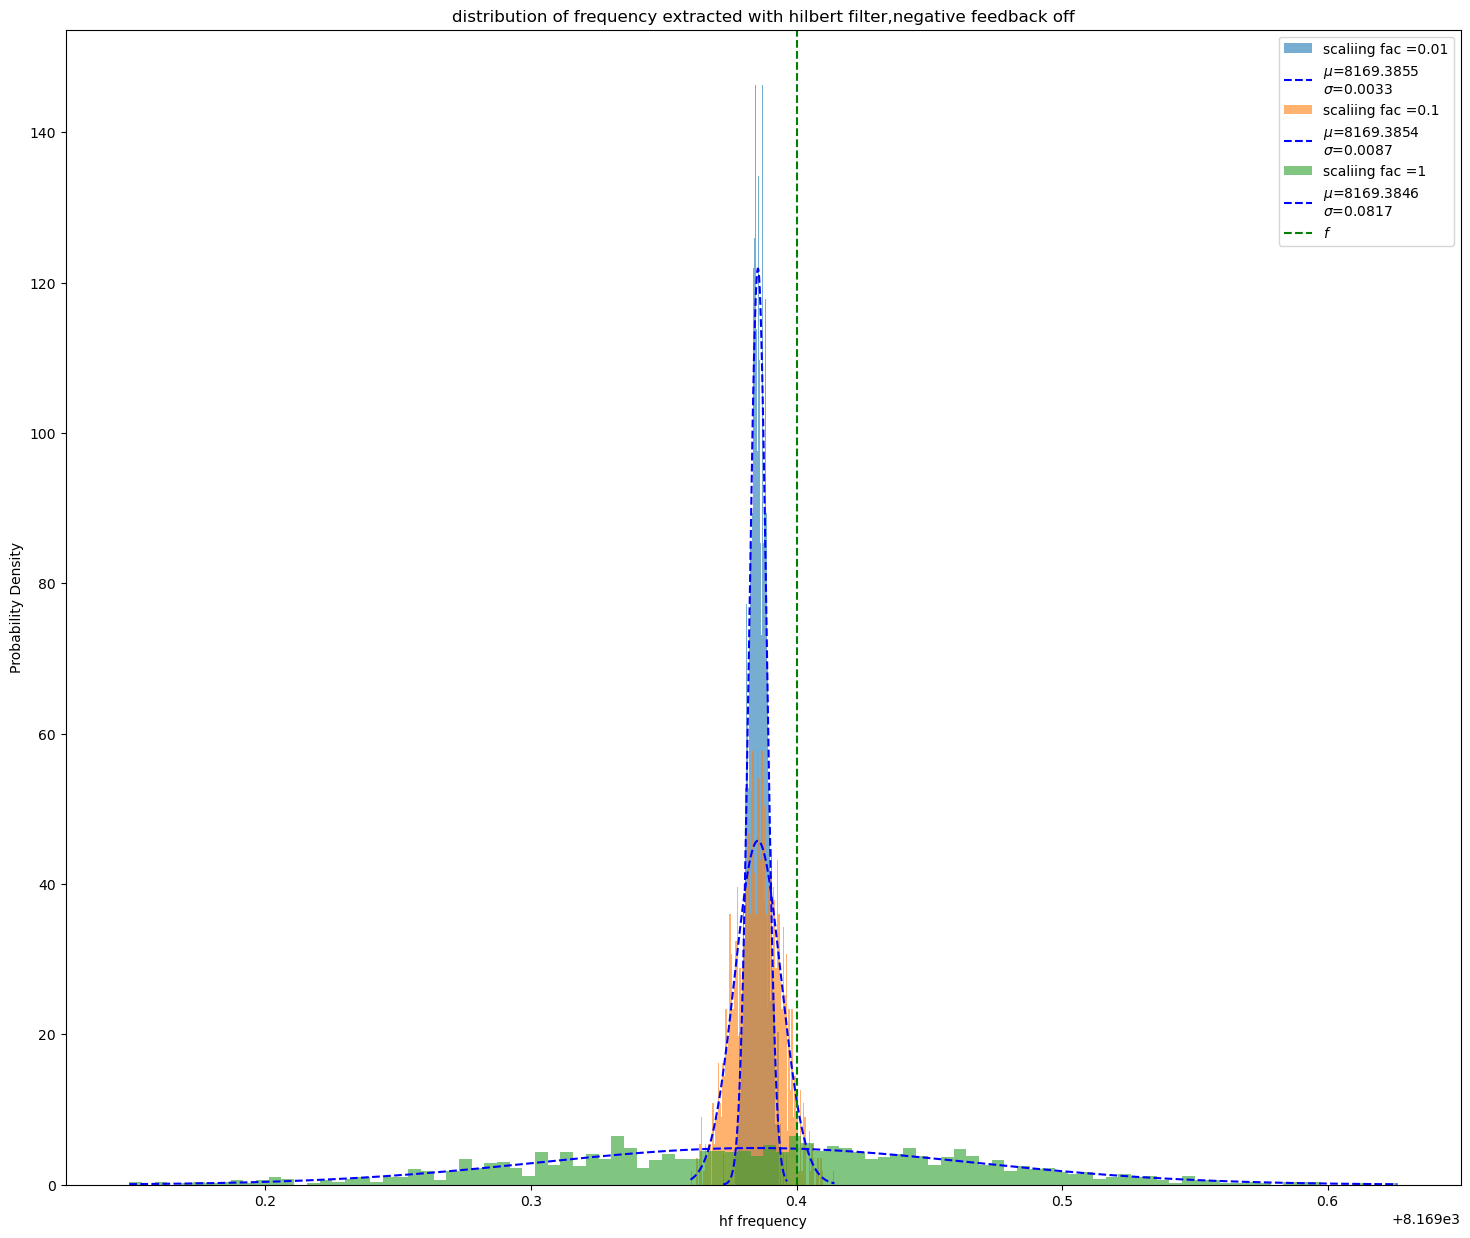

In [ ]:
import scipy.stats as stats


plt.figure(figsize=(18, 15))

for i in range((len(scaliingfac_l)) - 1):
    plt.hist(
        f_lowf_negoff_hf_l[i],
        bins=100,
        alpha=0.6,
        label="scaliing fac =" + str(scaliingfac_l[i]),
        density=True,
    )


    mu_negoff, std_negoff = stats.norm.fit(f_lowf_negoff_hf_l[i])

    xmin = min(f_lowf_negoff_hf_l[i])
    xmax = max(f_lowf_negoff_hf_l[i])
    x = np.linspace(xmin, xmax, 1000)


    plt.plot(
        x,
        stats.norm.pdf(x, mu_negoff, std_negoff),
        "b--",
        label=f"$\mu$={mu_negoff:.4f}\n$\sigma$={std_negoff:.4f}",
    )
plt.axvline(x=w1 / 2 / np.pi, color="g", linestyle="--", label=r"$f$")
plt.title(
    "distribution of frequency extracted with hilbert filter,negative feedback off"
)
plt.xlabel("hf frequency")
plt.ylabel("Probability Density")
plt.legend()

### negon, f

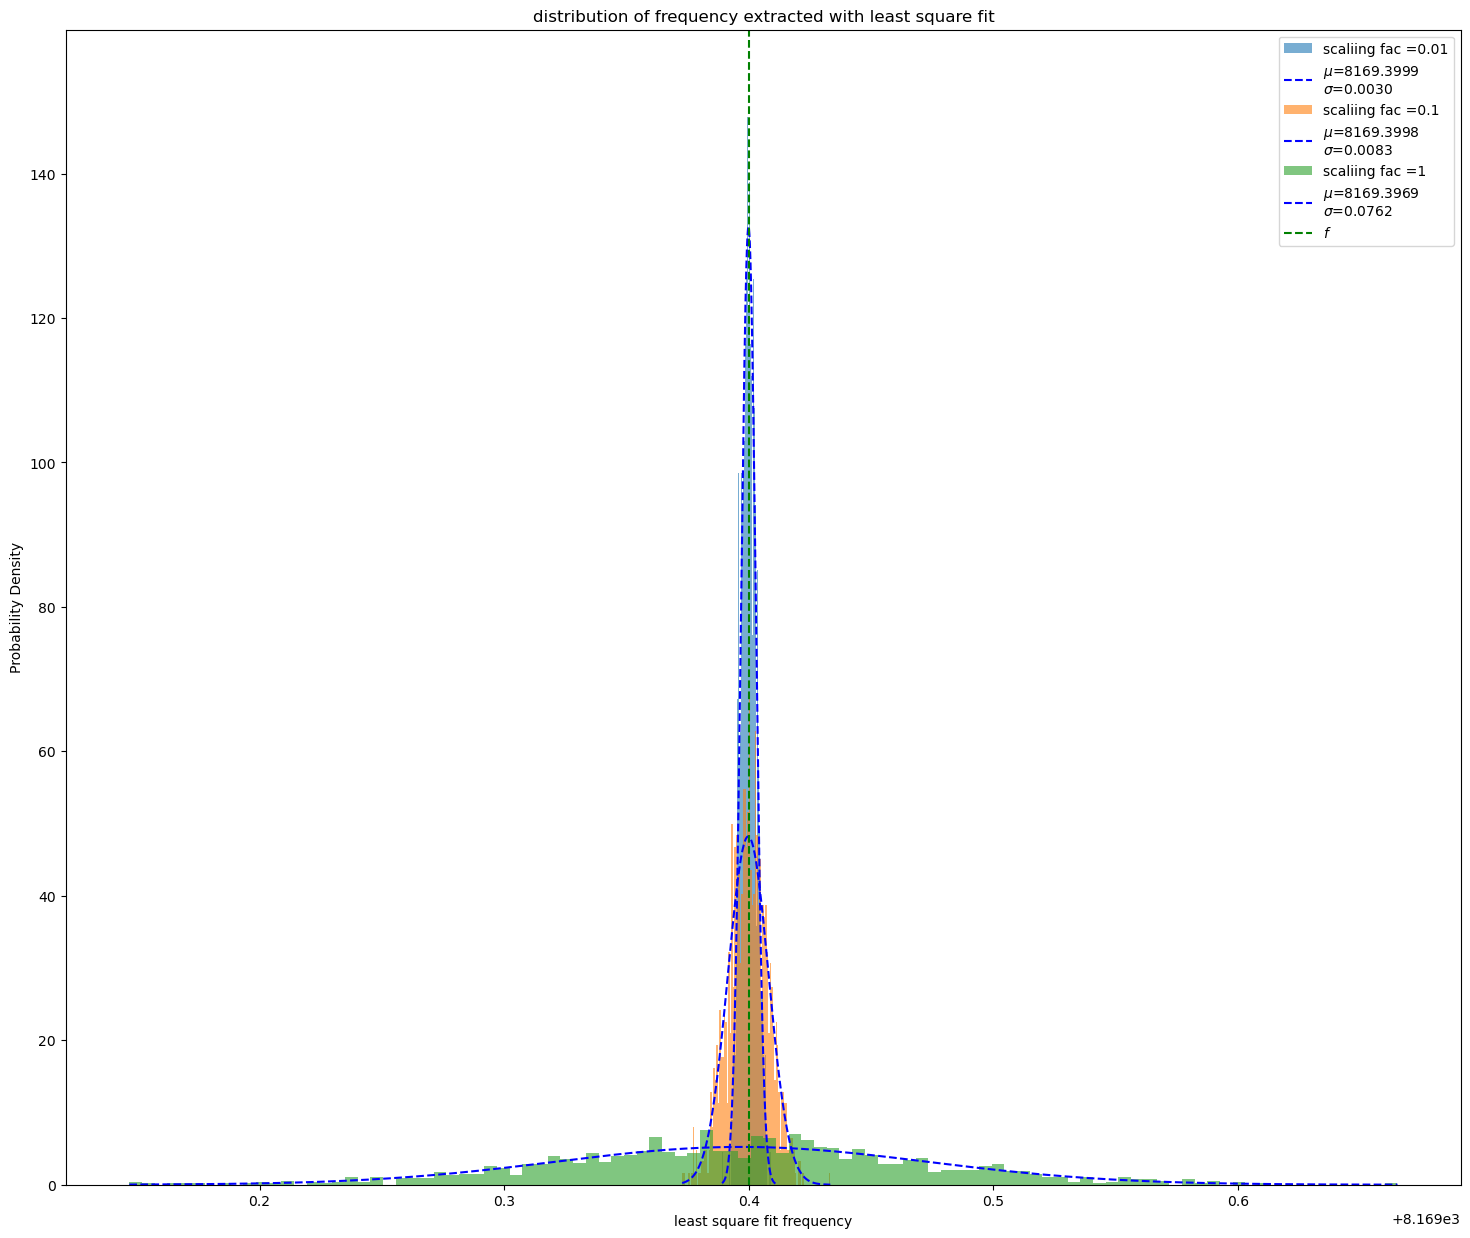

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(18, 15))

for i in range((len(scaliingfac_l)) - 1):
    plt.hist(
        f_lowf_negon_fit_l[i],
        bins=100,
        alpha=0.6,
        label="scaliing fac =" + str(scaliingfac_l[i]),
        density=True,
    )

    mu_negon, std_negon = stats.norm.fit(f_lowf_negon_fit_l[i])

    xmin = min(f_lowf_negon_fit_l[i])
    xmax = max(f_lowf_negon_fit_l[i])
    x = np.linspace(xmin, xmax, 1000)

    plt.plot(
        x,
        stats.norm.pdf(x, mu_negon, std_negon),
        "b--",
        label=f"$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
    )
plt.axvline(x=w1 / 2 / np.pi, color="g", linestyle="--", label=r"$f$")
plt.title(
    "distribution of frequency extracted with least square fit, negative feedback on"
)
plt.xlabel("least square fit frequency")
plt.ylabel("Probability Density")
plt.legend()

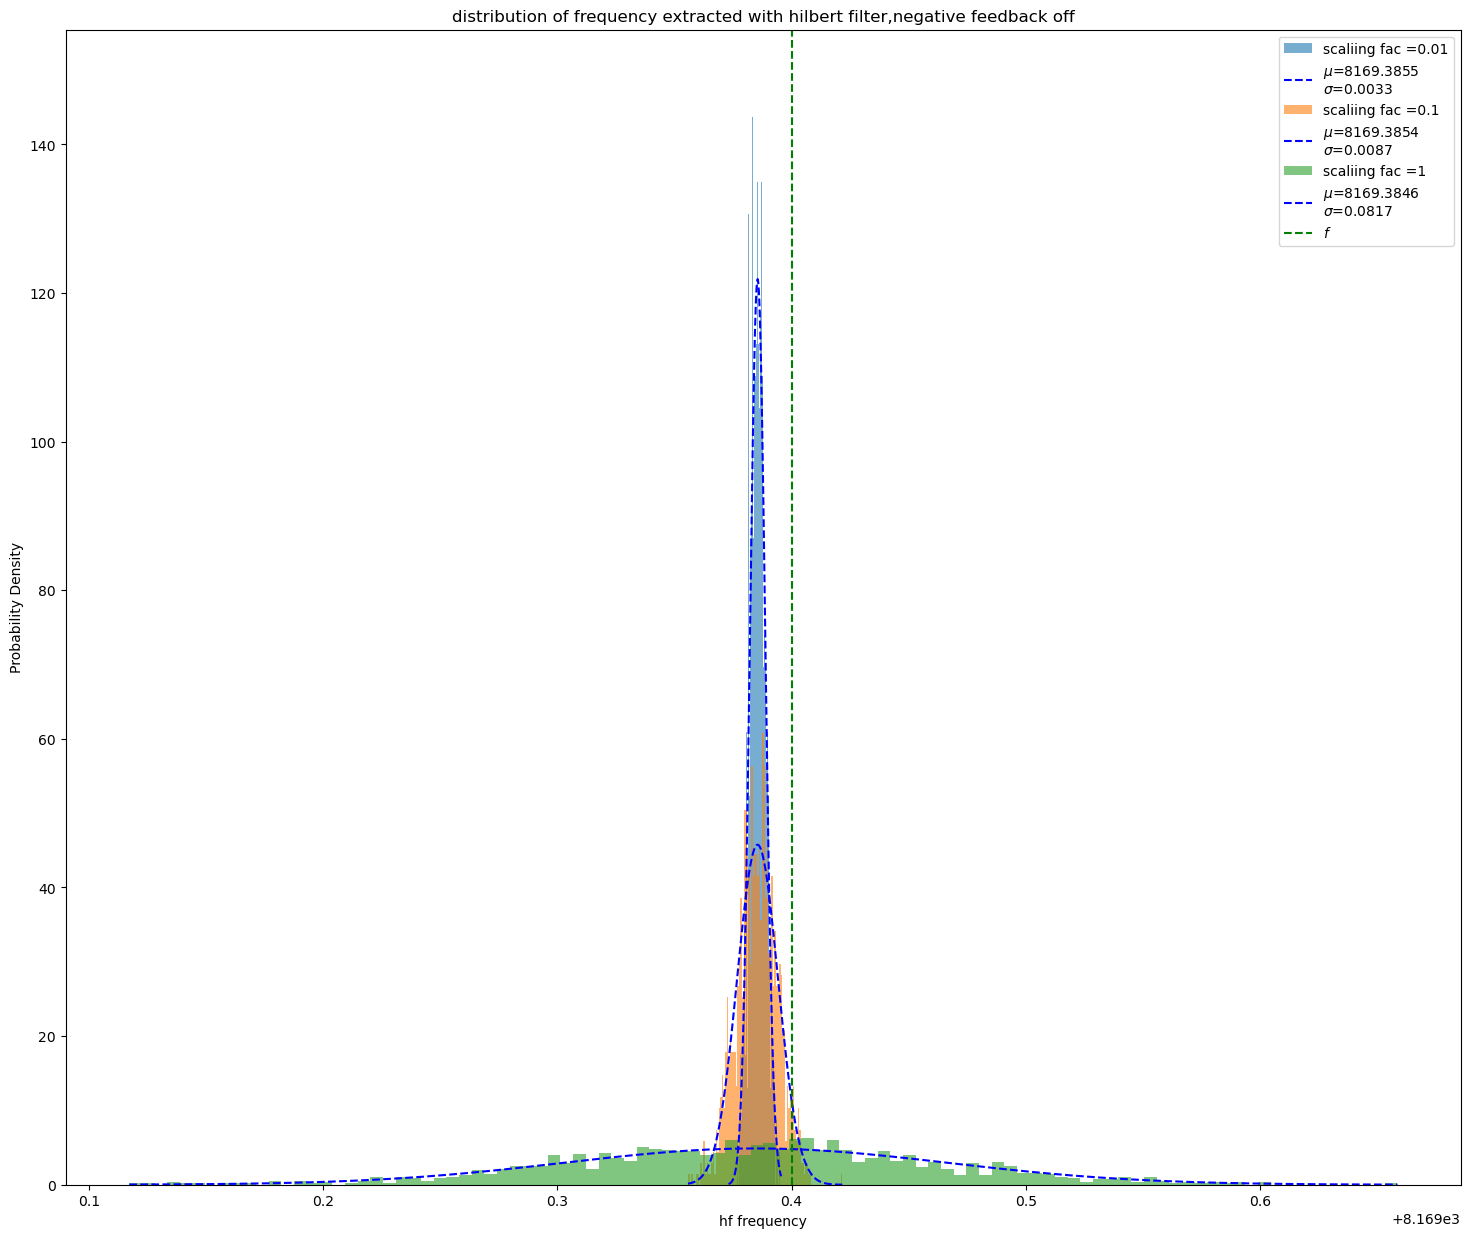

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(18, 15))

for i in range((len(scaliingfac_l)) - 1):
    plt.hist(
        f_lowf_negon_hf_l[i],
        bins=100,
        alpha=0.6,
        label="scaliing fac =" + str(scaliingfac_l[i]),
        density=True,
    )

    mu_negon, std_negon = stats.norm.fit(f_lowf_negoff_hf_l[i])

    xmin = min(f_lowf_negon_hf_l[i])
    xmax = max(f_lowf_negon_hf_l[i])
    x = np.linspace(xmin, xmax, 1000)

    plt.plot(
        x,
        stats.norm.pdf(x, mu_negon, std_negon),
        "b--",
        label=f"$\mu$={mu_negon:.4f}\n$\sigma$={std_negon:.4f}",
    )
plt.axvline(x=w1 / 2 / np.pi, color="g", linestyle="--", label=r"$f$")
plt.title(
    "distribution of frequency extracted with hilbert filter,negative feedback off"
)
plt.xlabel("hf frequency")
plt.ylabel("Probability Density")
plt.legend()

Okay, now we do see the change in distribution, if we keep the behavior of our noise the same, by varying the amplitude of our thermal noise, we do can change the freq noise, this shows us 2 things:

1. the freq noise is dominated by the thermal noise
2. the heating-up pattern of our neg on signal, introduce extra freq noise to our signal



# 6 Conclusion

In this notebook, we found that by using negative feedback, we successfully suppressed the noise in the zero-order parameters (x0, phi0), but did not manage to suppress the noise in the first-order parameter (f). This may be because negative feedback can only suppress the initial amplitude of the noise; on average, we only reduce the amplitude of the noise, but do not suppress the rate of change of the noise. Therefore, for the first-order parameter f, which is related to the derivative, its noise was not suppressed.

Furthermore, we should consider changing our measurement duration. Perhaps by further shortening the measurement time, we can observe more pronounced noise suppression. Although there is some concern that reducing measurement time may result in too few data points, as Russell mentioned, we can actually increase our sampling rate—setting it to, for instance, 1 GHz. This way, we would still have enough data points.
